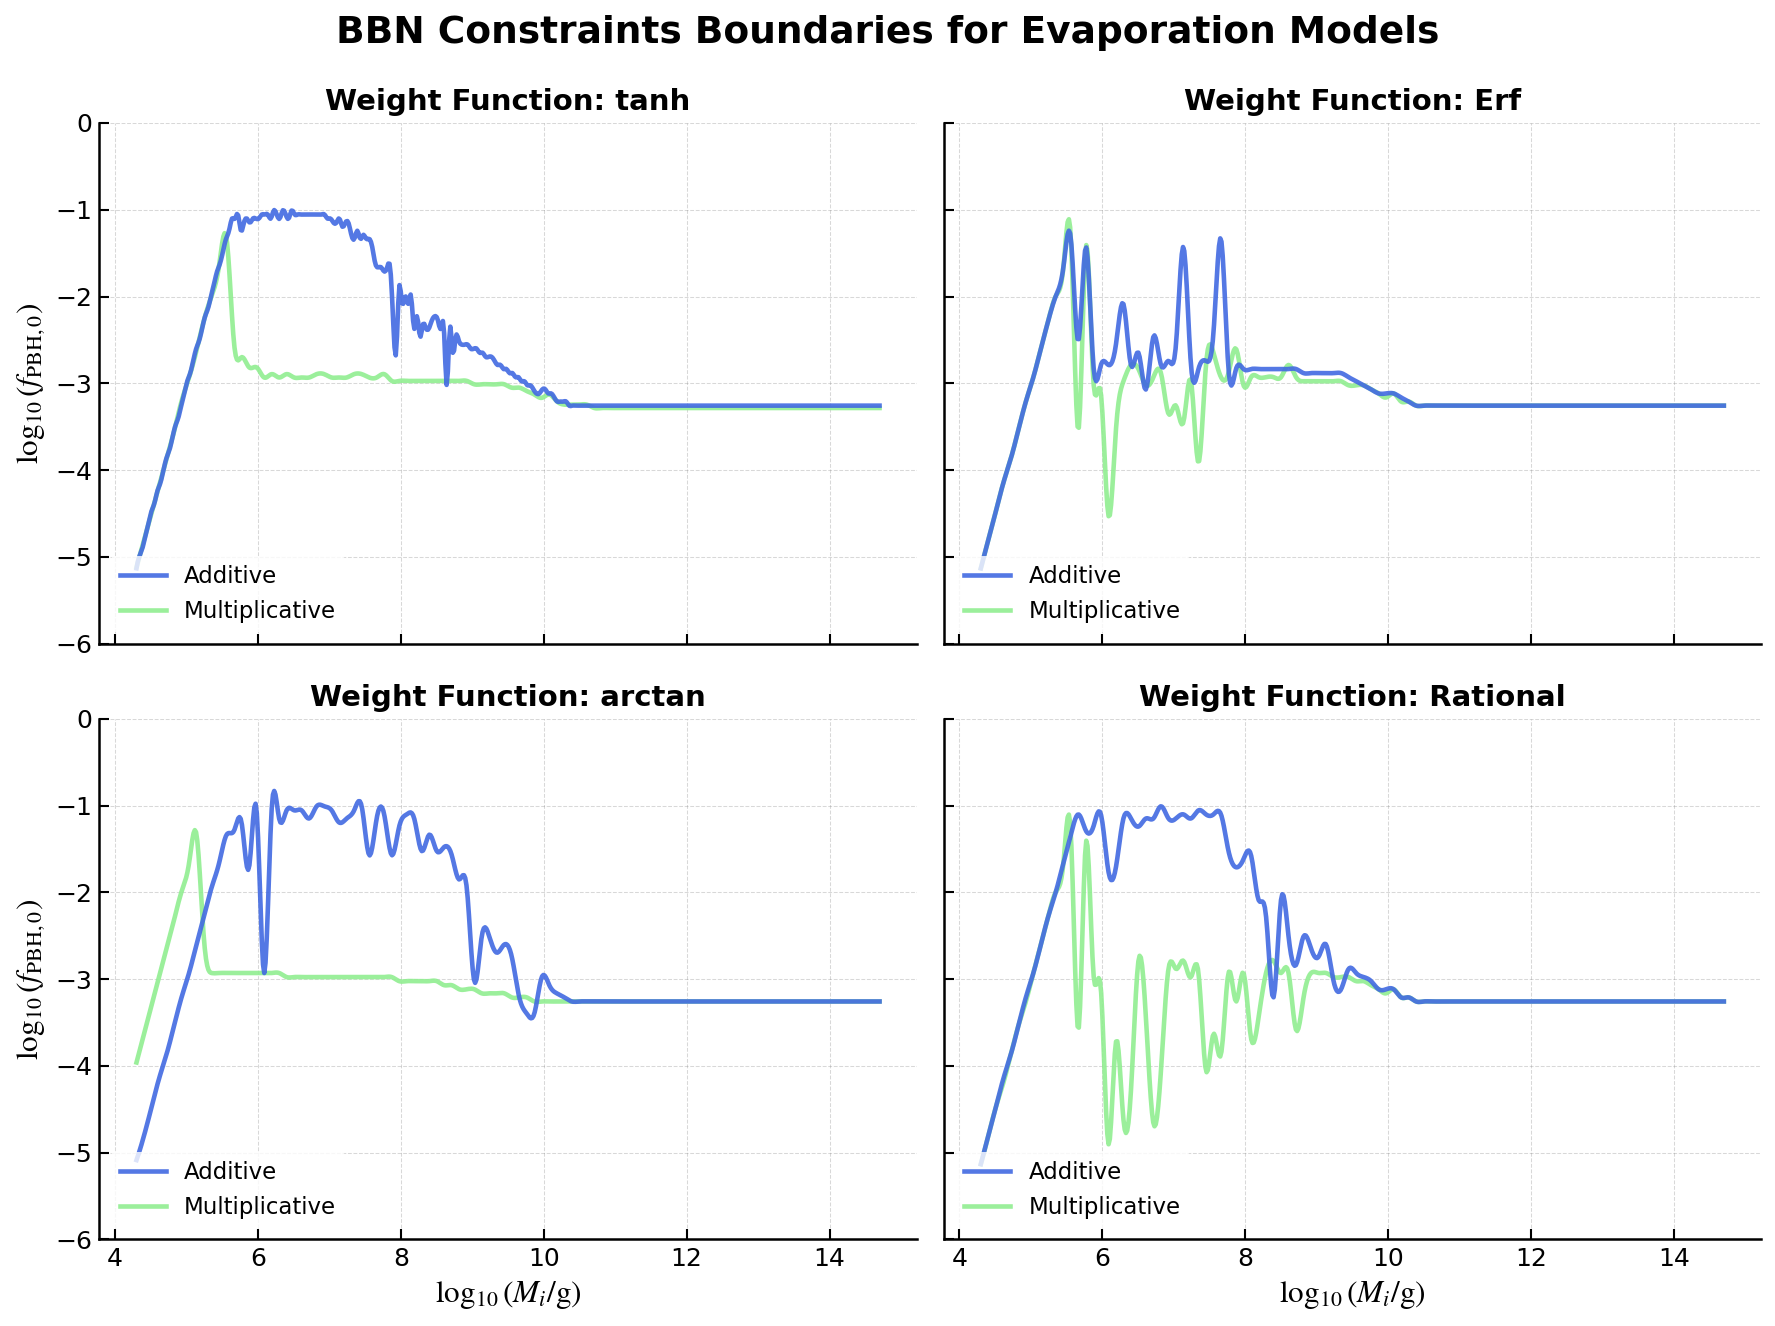

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import matplotlib as mpl
import os

# --- 出版级排版全局设置 ---
mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 15,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.2,
    'mathtext.fontset': 'stix', 
    'font.family': 'sans-serif',
})

# --- 定义映射规则 ---
func_map = {1: "tanh", 2: "Erf", 3: "arctan", 4: "Rational"}

# 创建 2x2 的图表阵列 (四个象限)
fig, axs = plt.subplots(2, 2, figsize=(12, 9), dpi=150, sharex=True, sharey=True)
axs_flat = axs.flatten()

# --- 核心绘图循环 ---
for f_idx in range(1, 5):
    ax = axs_flat[f_idx - 1]
    
    file_additive = f"bbn_boundary_results_0.5_0.1_{f_idx}.csv"
    file_multiplicative = f"bbn_boundary_results_0.5_0.1_{f_idx + 4}.csv"
    
    # 绘制 Additive 曲线 (宝蓝色，实线)
    if os.path.exists(file_additive):
        # 【修复处】先读取，再排序
        df_add = pd.read_csv(file_additive)
        df_add = df_add.sort_values(by=df_add.columns[0])
        
        x_add = df_add.iloc[:, 0].values
        y_add = df_add.iloc[:, 1].values
        
        x_smooth = np.linspace(x_add.min(), x_add.max(), 600)
        y_smooth_add = make_interp_spline(x_add, y_add, k=3)(x_smooth)
        
        ax.plot(x_smooth, y_smooth_add, color='royalblue', linestyle='-', 
                linewidth=2.2, alpha=0.9, zorder=3, label="Additive")
                
    # 绘制 Multiplicative 曲线 (浅绿色，实线)
    if os.path.exists(file_multiplicative):
        # 【修复处】先读取，再排序
        df_mult = pd.read_csv(file_multiplicative)
        df_mult = df_mult.sort_values(by=df_mult.columns[0])
        
        x_mult = df_mult.iloc[:, 0].values
        y_mult = df_mult.iloc[:, 1].values
        
        x_smooth_m = np.linspace(x_mult.min(), x_mult.max(), 600)
        y_smooth_mult = make_interp_spline(x_mult, y_mult, k=3)(x_smooth_m)
        
        ax.plot(x_smooth_m, y_smooth_mult, color='#90ee90', linestyle='-', 
                linewidth=2.2, alpha=0.9, zorder=2, label="Multiplicative")
                
    # --- 每个子图的独立修饰 ---
    ax.set_title(f"Weight Function: {func_map[f_idx]}", fontweight='bold')
    
    ax.grid(True, which="major", linestyle="--", linewidth=0.5, color='grey', alpha=0.3)
    ax.legend(loc='lower left', framealpha=0.8, edgecolor='none')
    ax.tick_params(axis='both', which='major', length=5, width=1.0, direction='in')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# --- 外部大图的全局修饰 ---
axs[0, 0].set_ylim(-6, 0)

for ax in axs[1, :]:
    ax.set_xlabel(r"$\log_{10}(M_i/\mathrm{g})$")

for ax in axs[:, 0]:
    ax.set_ylabel(r"$\log_{10}(f_{\mathrm{PBH},0})$")

fig.suptitle("BBN Constraints Boundaries for Evaporation Models", fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
fig.subplots_adjust(top=0.9) 

plt.show()

<>:56: SyntaxWarning: invalid escape sequence '\d'
<>:56: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_10408/4290525194.py:56: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title(f"Parameters: $q={q}$, $\delta={delta}$", fontweight='bold')


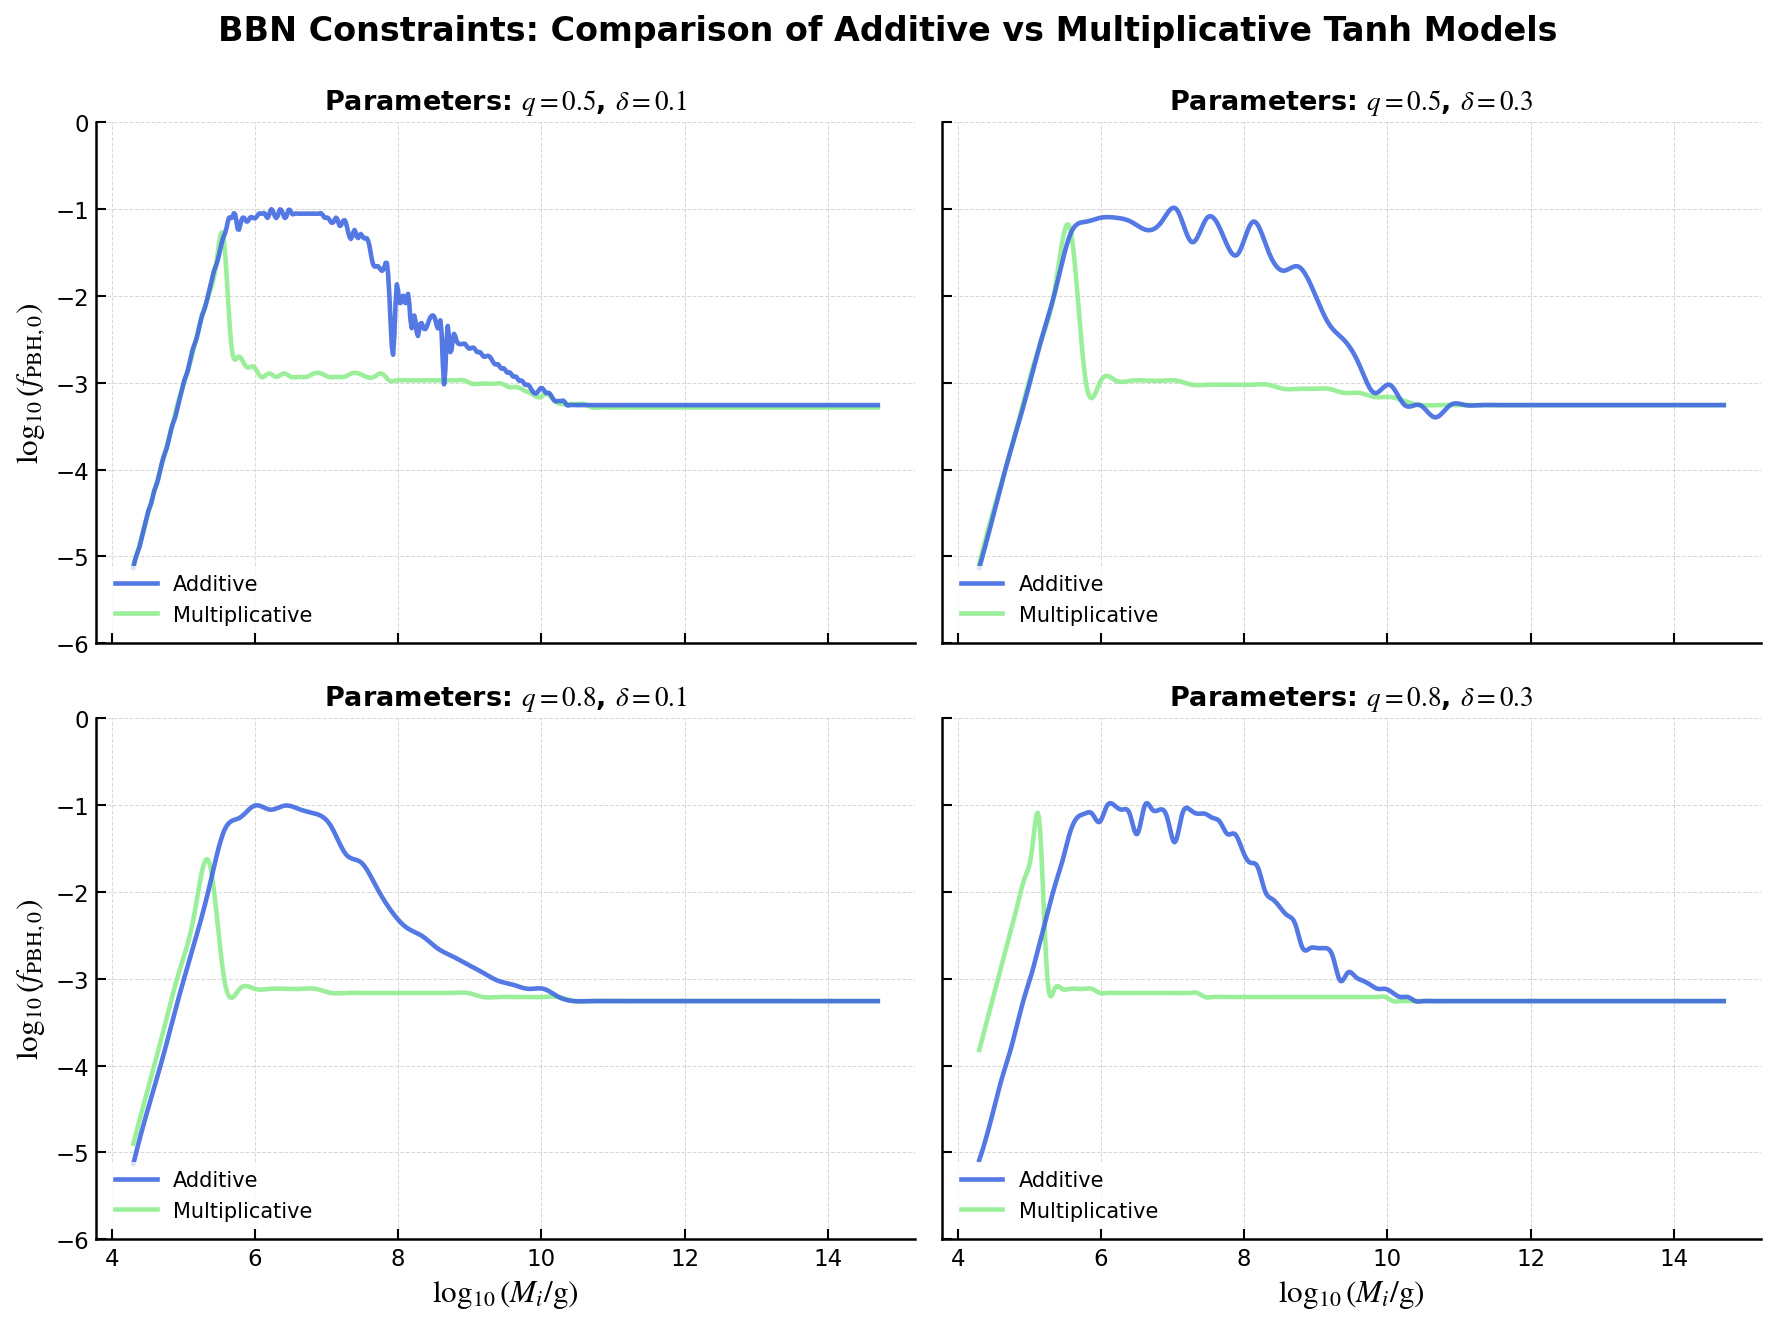

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import matplotlib as mpl
import os

# --- 出版级排版全局设置 ---
mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 15,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'axes.linewidth': 1.2,
    'mathtext.fontset': 'stix', 
    'font.family': 'sans-serif',
})

# --- 定义需要展示的 4 组参数组合 (q, delta) ---
# 我挑选了 4 个展示 delta 演变的组合
selected_groups = [
    ("0.5", "0.1"),
    ("0.5", "0.3"),
    ("0.8", "0.1"),
    ("0.8", "0.3")
]

fig, axs = plt.subplots(2, 2, figsize=(12, 9), dpi=150, sharex=True, sharey=True)
axs_flat = axs.flatten()

for idx, (q, delta) in enumerate(selected_groups):
    ax = axs_flat[idx]
    
    # 匹配对应的 Type 1 (Additive) 和 Type 5 (Multiplicative)
    file_1 = f"bbn_boundary_results_{q}_{delta}_1.csv"
    file_5 = f"bbn_boundary_results_{q}_{delta}_5.csv"
    
    # 绘图逻辑
    for file, color, label, z in [(file_1, 'royalblue', 'Additive', 3), 
                                  (file_5, '#90ee90', 'Multiplicative ', 2)]:
        if os.path.exists(file):
            df = pd.read_csv(file).sort_values(by=pd.read_csv(file).columns[0])
            x = df.iloc[:, 0].values
            y = df.iloc[:, 1].values
            
            # Spline 平滑
            x_smooth = np.linspace(x.min(), x.max(), 600)
            y_smooth = make_interp_spline(x, y, k=3)(x_smooth)
            
            ax.plot(x_smooth, y_smooth, color=color, linestyle='-', 
                    linewidth=2.2, alpha=0.9, zorder=z, label=label)
    
    # 子图修饰
    ax.set_title(f"Parameters: $q={q}$, $\delta={delta}$", fontweight='bold')
    ax.grid(True, which="major", linestyle="--", linewidth=0.5, color='grey', alpha=0.3)
    ax.legend(loc='lower left', framealpha=0.8, edgecolor='none')
    ax.tick_params(axis='both', which='major', length=5, width=1.0, direction='in')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 全局标签
axs[0, 0].set_ylim(-6, 0)
for ax in axs[1, :]: ax.set_xlabel(r"$\log_{10}(M_i/\mathrm{g})$")
for ax in axs[:, 0]: ax.set_ylabel(r"$\log_{10}(f_{\mathrm{PBH},0})$")

fig.suptitle("BBN Constraints: Comparison of Additive vs Multiplicative Tanh Models", 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
fig.subplots_adjust(top=0.9) 
plt.show()

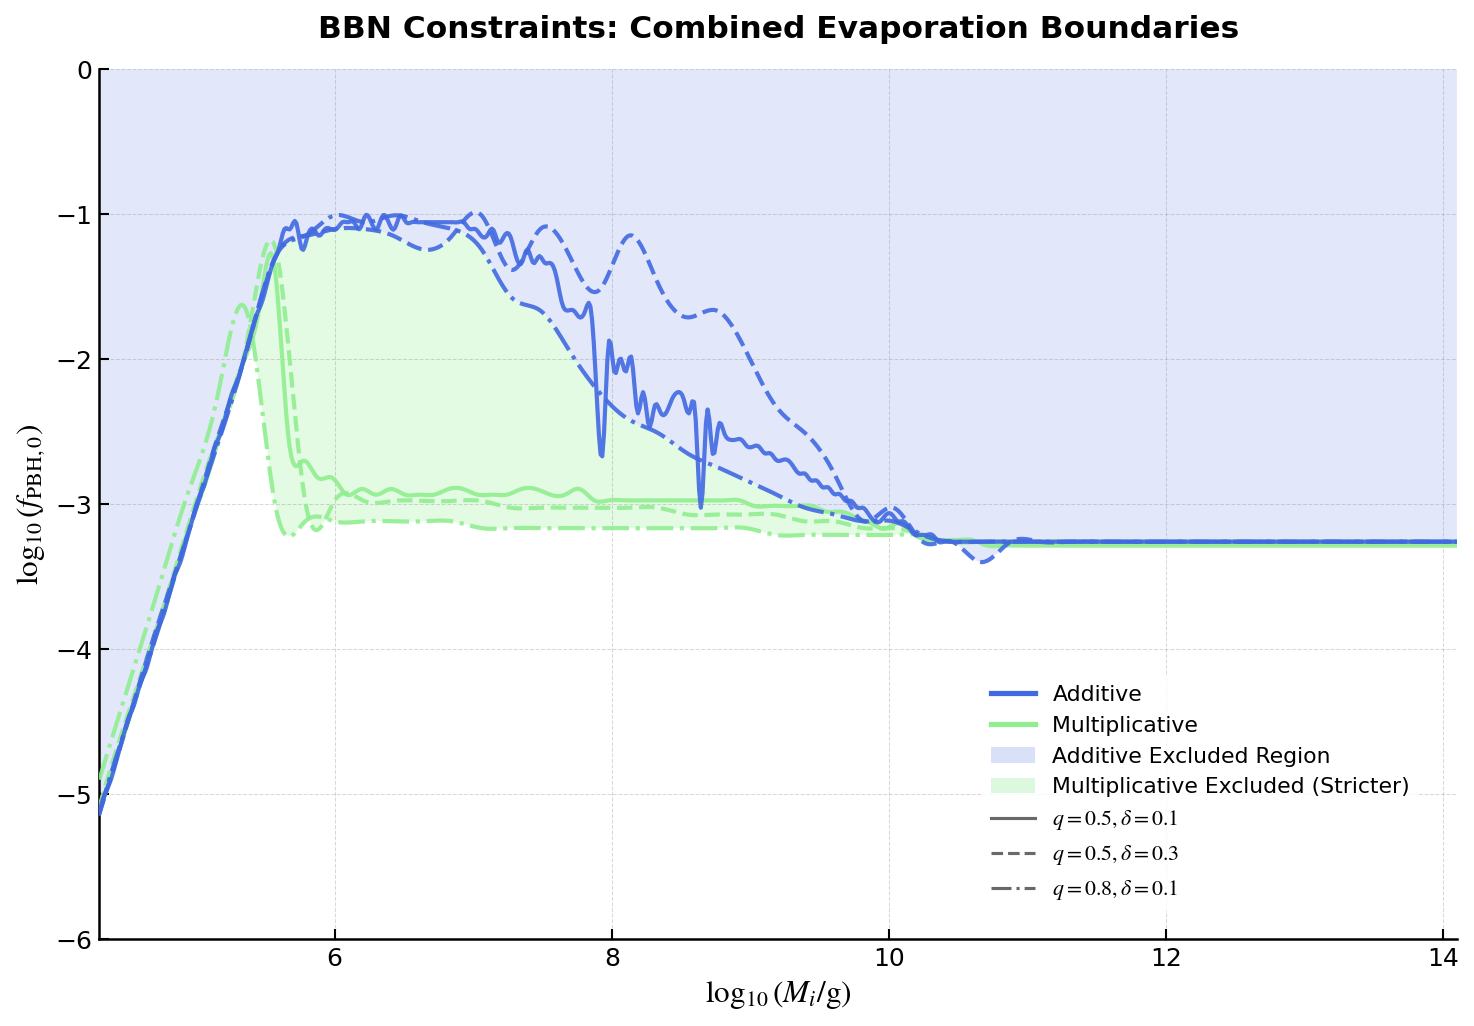

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import matplotlib as mpl
import os
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

# --- 出版级排版全局设置 ---
mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'legend.fontsize': 10.5,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.2,
    'mathtext.fontset': 'stix', 
    'font.family': 'sans-serif',
})

# --- 参数组与样式定义 ---
groups = [("0.5", "0.1"), ("0.5", "0.3"), ("0.8", "0.1")]
styles = ['-', '--', '-.']

# 精确指定 X 轴的数据范围
x_start = 4.30102999566398
x_end = 14.1
x_common = np.linspace(x_start, x_end, 800)

y_add_all = []
y_mult_all = []

fig, ax = plt.subplots(figsize=(10, 7), dpi=150)

# --- 核心绘图与数据收集循环 ---
for idx, (q, delta) in enumerate(groups):
    ls = styles[idx]
    file_1 = f"bbn_boundary_results_{q}_{delta}_1.csv"
    file_5 = f"bbn_boundary_results_{q}_{delta}_5.csv"
    
    # 绘制 Additive 曲线
    if os.path.exists(file_1):
        df_add = pd.read_csv(file_1).sort_values(by=pd.read_csv(file_1).columns[0])
        x_add, y_add = df_add.iloc[:, 0].values, df_add.iloc[:, 1].values
        y_interp_add = make_interp_spline(x_add, y_add, k=3)(x_common)
        y_add_all.append(y_interp_add)
        ax.plot(x_common, y_interp_add, color='royalblue', linestyle=ls, linewidth=2.0, alpha=0.9, zorder=4)
                
    # 绘制 Multiplicative 曲线
    if os.path.exists(file_5):
        df_mult = pd.read_csv(file_5).sort_values(by=pd.read_csv(file_5).columns[0])
        x_mult, y_mult = df_mult.iloc[:, 0].values, df_mult.iloc[:, 1].values
        y_interp_mult = make_interp_spline(x_mult, y_mult, k=3)(x_common)
        y_mult_all.append(y_interp_mult)
        ax.plot(x_common, y_interp_mult, color='#90ee90', linestyle=ls, linewidth=2.0, alpha=0.9, zorder=3)

# --- 包络线计算与优先级渲染 ---
if y_add_all and y_mult_all:
    y_add_env = np.min(y_add_all, axis=0)
    y_mult_env = np.min(y_mult_all, axis=0)
    
    # 优先渲染 Additive 排除区 (淡蓝色)
    ax.fill_between(x_common, y_add_env, 0, facecolor='royalblue', alpha=0.15, zorder=1)
    
    # 渲染 Multiplicative 更严格的区域 (淡绿色)
    ax.fill_between(x_common, y_mult_env, y_add_env, 
                    where=(y_mult_env < y_add_env), 
                    facecolor='#90ee90', alpha=0.25, zorder=1)

# --- 全局修饰 ---
ax.set_ylim(-6, 0)

# 【核心修改区】强制收紧 X 轴，消除左右白边
ax.set_xlim(left=x_start, right=x_end)

ax.set_xlabel(r"$\log_{10}(M_i/\mathrm{g})$")
ax.set_ylabel(r"$\log_{10}(f_{\mathrm{PBH},0})$")
ax.set_title("BBN Constraints: Combined Evaporation Boundaries", fontweight='bold', pad=15)

ax.grid(True, which="major", linestyle="--", linewidth=0.5, color='grey', alpha=0.3)
ax.tick_params(axis='both', which='major', length=5, width=1.0, direction='in')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- 自定义组合图例 ---
legend_elements = [
    mlines.Line2D([0], [0], color='royalblue', lw=2.5, label='Additive'),
    mlines.Line2D([0], [0], color='#90ee90', lw=2.5, label='Multiplicative '),
    mpatches.Patch(facecolor='royalblue', alpha=0.2, label='Additive Excluded Region'),
    mpatches.Patch(facecolor='#90ee90', alpha=0.3, label='Multiplicative Excluded (Stricter)'),
    mlines.Line2D([0], [0], color='dimgrey', ls='-', lw=1.5, label=r'$q=0.5, \delta=0.1$'),
    mlines.Line2D([0], [0], color='dimgrey', ls='--', lw=1.5, label=r'$q=0.5, \delta=0.3$'),
    mlines.Line2D([0], [0], color='dimgrey', ls='-.', lw=1.5, label=r'$q=0.8, \delta=0.1$')
]

ax.legend(handles=legend_elements, loc='lower right', framealpha=0.85, 
          edgecolor='none', bbox_to_anchor=(0.98, 0.02))

plt.tight_layout()
plt.show()

<>:80: SyntaxWarning: invalid escape sequence '\d'
<>:80: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_10408/3746168174.py:80: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title(f"Parameters: $q={q}$, $\delta={delta}$", fontweight='bold')


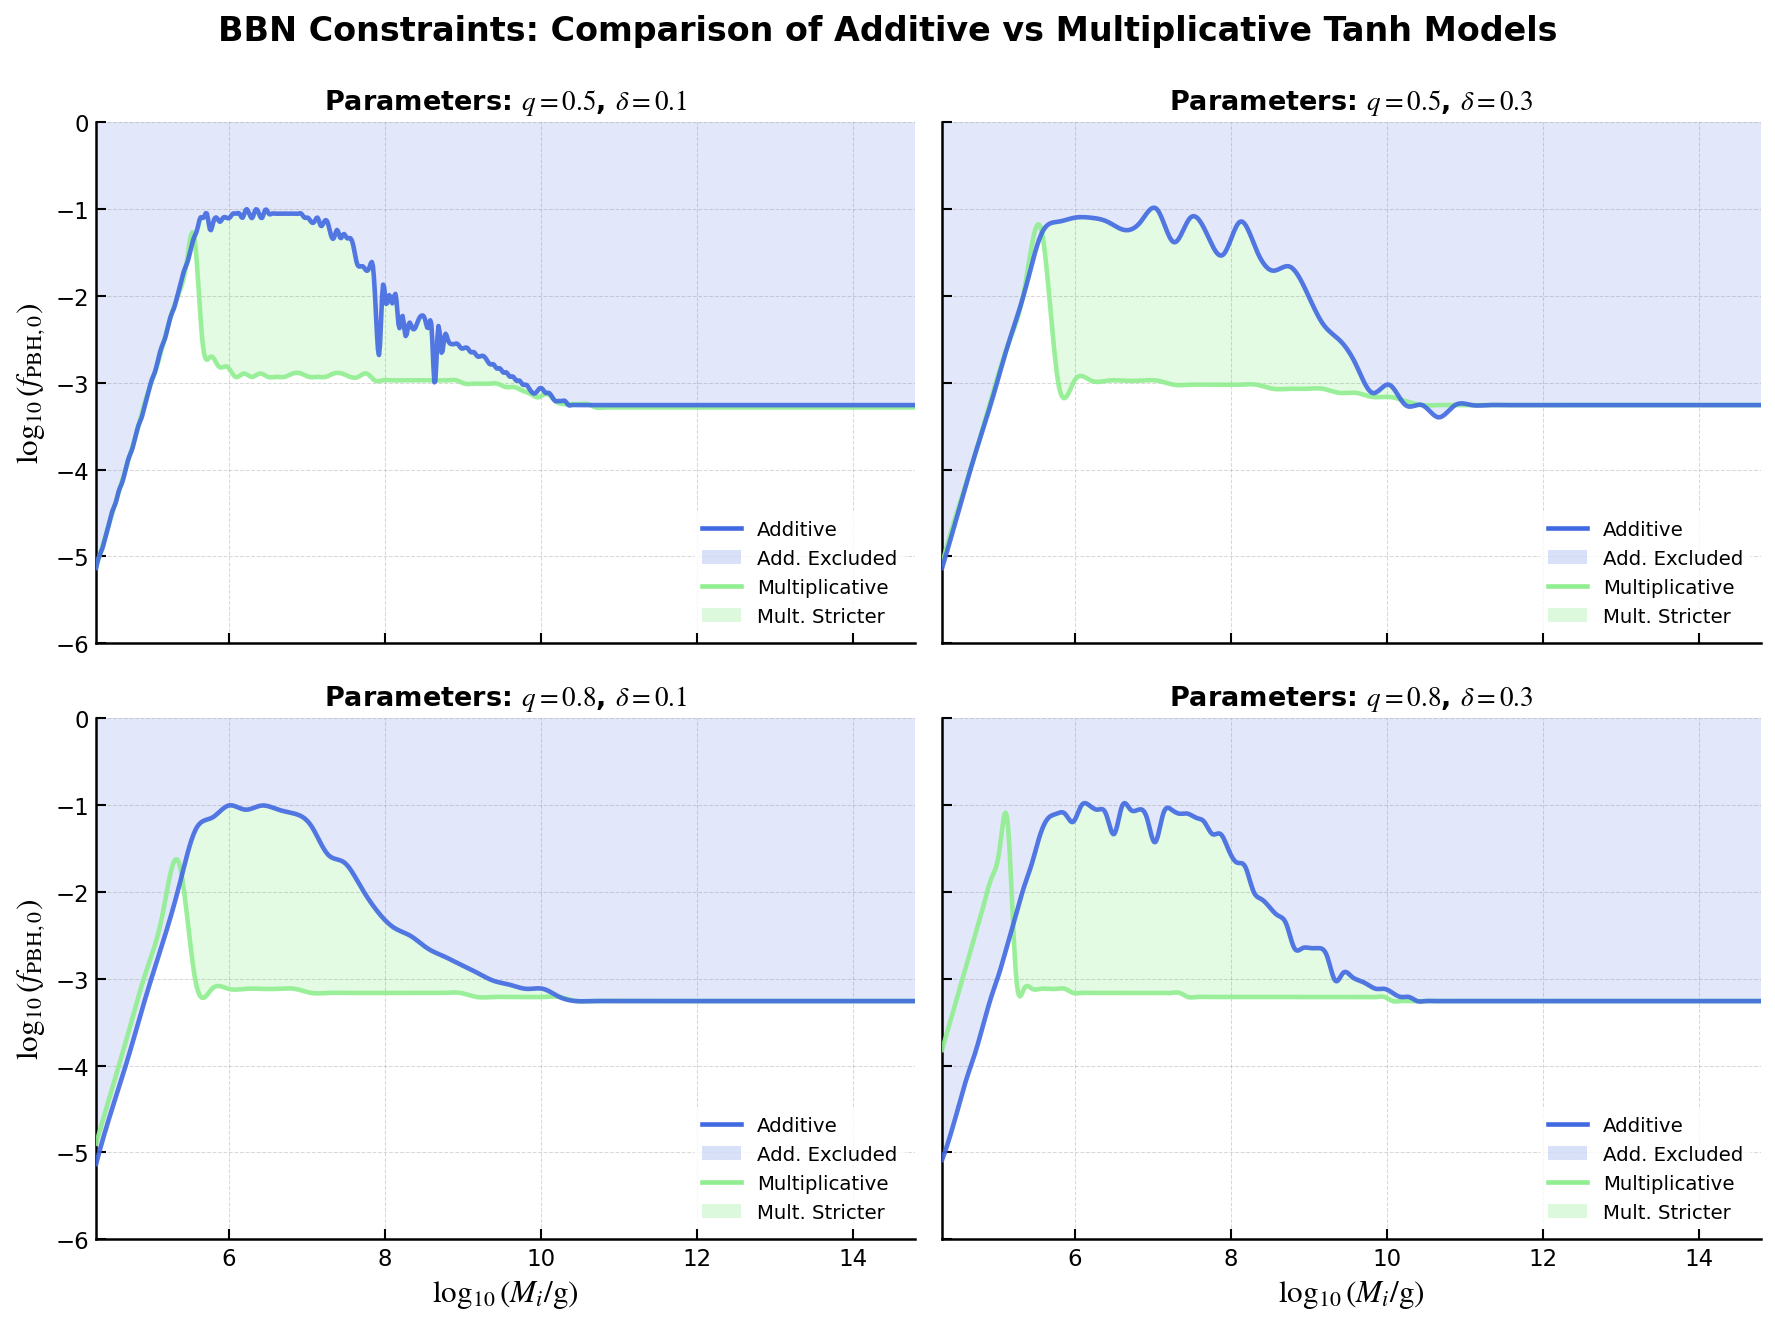

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import matplotlib as mpl
import os
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

# --- 出版级排版全局设置 ---
mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 15,
    'axes.titlesize': 13,
    'legend.fontsize': 9.5, 
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'axes.linewidth': 1.2,
    'mathtext.fontset': 'stix', 
    'font.family': 'sans-serif',
})

# --- 定义需要展示的 4 组参数组合 (q, delta) ---
selected_groups = [
    ("0.5", "0.1"),
    ("0.5", "0.3"),
    ("0.8", "0.1"),
    ("0.8", "0.3")
]

# 精确指定 X 轴的数据范围以消除空白
x_start = 4.30102999566398
x_end = 14.8
x_common = np.linspace(x_start, x_end, 800)

fig, axs = plt.subplots(2, 2, figsize=(12, 9), dpi=150, sharex=True, sharey=True)
axs_flat = axs.flatten()

for idx, (q, delta) in enumerate(selected_groups):
    ax = axs_flat[idx]
    
    file_1 = f"bbn_boundary_results_{q}_{delta}_1.csv"
    file_5 = f"bbn_boundary_results_{q}_{delta}_5.csv"
    
    y_add_env = None
    y_mult_env = None
    
    # 1. 提取并绘制 Additive 曲线
    if os.path.exists(file_1):
        df_add = pd.read_csv(file_1).sort_values(by=pd.read_csv(file_1).columns[0])
        x_add, y_add = df_add.iloc[:, 0].values, df_add.iloc[:, 1].values
        
        y_add_env = make_interp_spline(x_add, y_add, k=3)(x_common)
        ax.plot(x_common, y_add_env, color='royalblue', linestyle='-', 
                linewidth=2.2, alpha=0.9, zorder=4)
                
    # 2. 提取并绘制 Multiplicative 曲线
    if os.path.exists(file_5):
        df_mult = pd.read_csv(file_5).sort_values(by=pd.read_csv(file_5).columns[0])
        x_mult, y_mult = df_mult.iloc[:, 0].values, df_mult.iloc[:, 1].values
        
        y_mult_env = make_interp_spline(x_mult, y_mult, k=3)(x_common)
        ax.plot(x_common, y_mult_env, color='#90ee90', linestyle='-', 
                linewidth=2.2, alpha=0.9, zorder=3)

    # 3. 执行阴影渲染逻辑 (带有优先级判断)
    if y_add_env is not None and y_mult_env is not None:
        # 优先渲染 Additive 排除区 (淡蓝色)
        ax.fill_between(x_common, y_add_env, 0, facecolor='royalblue', alpha=0.15, zorder=1)
        # 渲染 Multiplicative 更严格的区域 (淡绿色，仅在低于 Additive 时)
        ax.fill_between(x_common, y_mult_env, y_add_env, 
                        where=(y_mult_env < y_add_env), 
                        facecolor='#90ee90', alpha=0.25, zorder=1)
    elif y_add_env is not None:
        ax.fill_between(x_common, y_add_env, 0, facecolor='royalblue', alpha=0.15, zorder=1)
    elif y_mult_env is not None:
        ax.fill_between(x_common, y_mult_env, 0, facecolor='#90ee90', alpha=0.25, zorder=1)

    # 4. 子图修饰
    ax.set_title(f"Parameters: $q={q}$, $\delta={delta}$", fontweight='bold')
    ax.grid(True, which="major", linestyle="--", linewidth=0.5, color='grey', alpha=0.3)
    ax.tick_params(axis='both', which='major', length=5, width=1.0, direction='in')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 强制收紧每个子图的 X 轴
    ax.set_xlim(left=x_start, right=x_end)
    
    # 5. 为每个子图生成对应的图例
    legend_elements = []
    if y_add_env is not None:
        legend_elements.append(mlines.Line2D([0], [0], color='royalblue', lw=2.2, label='Additive'))
        legend_elements.append(mpatches.Patch(facecolor='royalblue', alpha=0.2, label='Add. Excluded'))
    if y_mult_env is not None:
        legend_elements.append(mlines.Line2D([0], [0], color='#90ee90', lw=2.2, label='Multiplicative'))
        legend_elements.append(mpatches.Patch(facecolor='#90ee90', alpha=0.3, label='Mult. Stricter'))
    
    if legend_elements:
        # 【核心修改】将 loc 设置为 'lower right'
        ax.legend(handles=legend_elements, loc='lower right', framealpha=0.8, edgecolor='none')

# --- 全局标签 ---
axs[0, 0].set_ylim(-6, 0)
for ax in axs[1, :]: ax.set_xlabel(r"$\log_{10}(M_i/\mathrm{g})$")
for ax in axs[:, 0]: ax.set_ylabel(r"$\log_{10}(f_{\mathrm{PBH},0})$")

fig.suptitle("BBN Constraints: Comparison of Additive vs Multiplicative Tanh Models", 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
fig.subplots_adjust(top=0.9) 
plt.show()

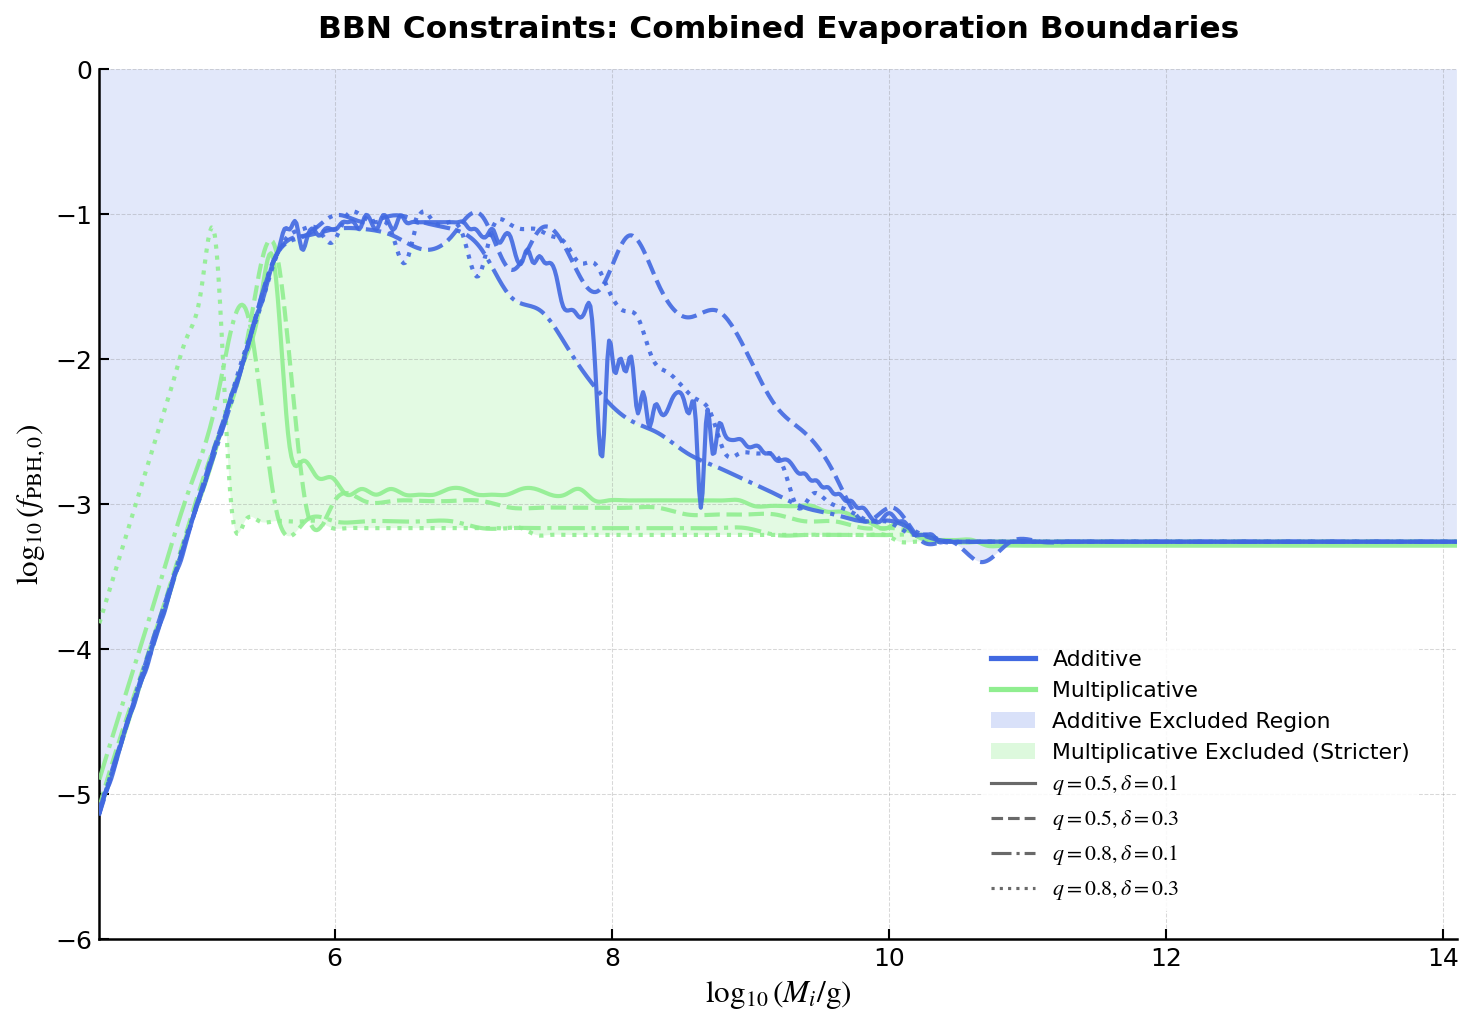

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import matplotlib as mpl
import os
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

# --- 出版级排版全局设置 ---
mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'legend.fontsize': 10.5,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.2,
    'mathtext.fontset': 'stix', 
    'font.family': 'sans-serif',
})

# --- 参数组与样式定义 ---
# 【修改处】新增 ("0.8", "0.3") 数据组
groups = [("0.5", "0.1"), ("0.5", "0.3"), ("0.8", "0.1"), ("0.8", "0.3")]
# 【修改处】新增第四种线形：点线 ':'
styles = ['-', '--', '-.', ':'] 

# 精确指定 X 轴的数据范围
x_start = 4.30102999566398
x_end = 14.1
x_common = np.linspace(x_start, x_end, 800)

y_add_all = []
y_mult_all = []

fig, ax = plt.subplots(figsize=(10, 7), dpi=150)

# --- 核心绘图与数据收集循环 ---
for idx, (q, delta) in enumerate(groups):
    ls = styles[idx]
    file_1 = f"bbn_boundary_results_{q}_{delta}_1.csv"
    file_5 = f"bbn_boundary_results_{q}_{delta}_5.csv"
    
    # 绘制 Additive 曲线
    if os.path.exists(file_1):
        df_add = pd.read_csv(file_1).sort_values(by=pd.read_csv(file_1).columns[0])
        x_add, y_add = df_add.iloc[:, 0].values, df_add.iloc[:, 1].values
        y_interp_add = make_interp_spline(x_add, y_add, k=3)(x_common)
        y_add_all.append(y_interp_add)
        ax.plot(x_common, y_interp_add, color='royalblue', linestyle=ls, linewidth=2.0, alpha=0.9, zorder=4)
                
    # 绘制 Multiplicative 曲线
    if os.path.exists(file_5):
        df_mult = pd.read_csv(file_5).sort_values(by=pd.read_csv(file_5).columns[0])
        x_mult, y_mult = df_mult.iloc[:, 0].values, df_mult.iloc[:, 1].values
        y_interp_mult = make_interp_spline(x_mult, y_mult, k=3)(x_common)
        y_mult_all.append(y_interp_mult)
        ax.plot(x_common, y_interp_mult, color='#90ee90', linestyle=ls, linewidth=2.0, alpha=0.9, zorder=3)

# --- 包络线计算与优先级渲染 ---
if y_add_all and y_mult_all:
    y_add_env = np.min(y_add_all, axis=0)
    y_mult_env = np.min(y_mult_all, axis=0)
    
    # 优先渲染 Additive 排除区 (淡蓝色)
    ax.fill_between(x_common, y_add_env, 0, facecolor='royalblue', alpha=0.15, zorder=1)
    
    # 渲染 Multiplicative 更严格的区域 (淡绿色)
    ax.fill_between(x_common, y_mult_env, y_add_env, 
                    where=(y_mult_env < y_add_env), 
                    facecolor='#90ee90', alpha=0.25, zorder=1)

# --- 全局修饰 ---
ax.set_ylim(-6, 0)

# 强制收紧 X 轴，消除左右白边
ax.set_xlim(left=x_start, right=x_end)

ax.set_xlabel(r"$\log_{10}(M_i/\mathrm{g})$")
ax.set_ylabel(r"$\log_{10}(f_{\mathrm{PBH},0})$")
ax.set_title("BBN Constraints: Combined Evaporation Boundaries", fontweight='bold', pad=15)

ax.grid(True, which="major", linestyle="--", linewidth=0.5, color='grey', alpha=0.3)
ax.tick_params(axis='both', which='major', length=5, width=1.0, direction='in')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- 自定义组合图例 ---
legend_elements = [
    mlines.Line2D([0], [0], color='royalblue', lw=2.5, label='Additive'),
    mlines.Line2D([0], [0], color='#90ee90', lw=2.5, label='Multiplicative '),
    mpatches.Patch(facecolor='royalblue', alpha=0.2, label='Additive Excluded Region'),
    mpatches.Patch(facecolor='#90ee90', alpha=0.3, label='Multiplicative Excluded (Stricter)'),
    mlines.Line2D([0], [0], color='dimgrey', ls='-', lw=1.5, label=r'$q=0.5, \delta=0.1$'),
    mlines.Line2D([0], [0], color='dimgrey', ls='--', lw=1.5, label=r'$q=0.5, \delta=0.3$'),
    mlines.Line2D([0], [0], color='dimgrey', ls='-.', lw=1.5, label=r'$q=0.8, \delta=0.1$'),
    # 【修改处】图例中新增第四组的点线标识
    mlines.Line2D([0], [0], color='dimgrey', ls=':', lw=1.5, label=r'$q=0.8, \delta=0.3$')
]

ax.legend(handles=legend_elements, loc='lower right', framealpha=0.85, 
          edgecolor='none', bbox_to_anchor=(0.98, 0.02))

plt.tight_layout()
plt.show()

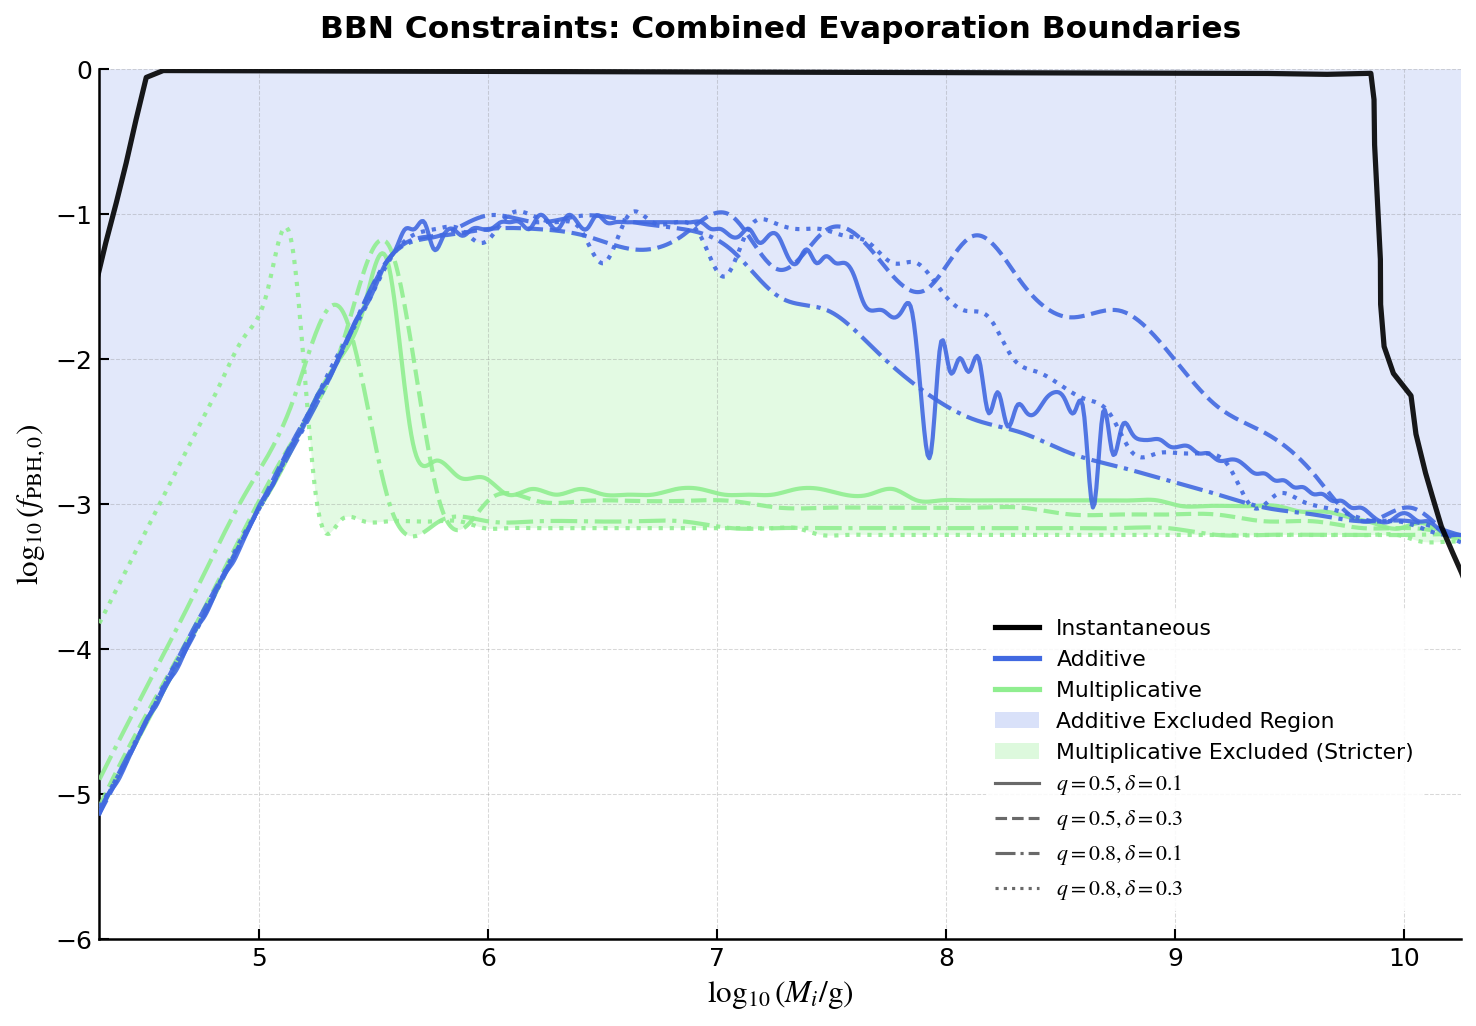

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import matplotlib as mpl
import os
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

# --- 出版级排版全局设置 ---
mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'legend.fontsize': 10.5,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.2,
    'mathtext.fontset': 'stix', 
    'font.family': 'sans-serif',
})

# --- 参数组与样式定义 ---
groups = [("0.5", "0.1"), ("0.5", "0.3"), ("0.8", "0.1"), ("0.8", "0.3")]
styles = ['-', '--', '-.', ':'] 

# 【请确认】将这里的字符串替换为你实际的 instantaneous 数据文件名
file_inst = "instantaneous.csv"

# 精确指定 X 轴的数据范围
x_start = 4.30102999566398
x_end = 10.25
x_common = np.linspace(x_start, x_end, 800)

y_add_all = []
y_mult_all = []

fig, ax = plt.subplots(figsize=(10, 7), dpi=150)

# --- 绘制 Instantaneous 极限基准线 (使用 Line) ---
if os.path.exists(file_inst):
    df_inst = pd.read_csv(file_inst).sort_values(by=pd.read_csv(file_inst).columns[0])
    x_inst, y_inst = df_inst.iloc[:, 0].values, df_inst.iloc[:, 1].values
    
    # 【修改处】不使用 Spline 平滑插值，直接使用 Line 连接原始数据点
    ax.plot(x_inst, y_inst, color='black', linestyle='-', 
            linewidth=2.5, alpha=0.9, zorder=5)

# --- 核心绘图与数据收集循环 ---
for idx, (q, delta) in enumerate(groups):
    ls = styles[idx]
    file_1 = f"bbn_boundary_results_{q}_{delta}_1.csv"
    file_5 = f"bbn_boundary_results_{q}_{delta}_5.csv"
    
    # 绘制 Additive 曲线 (使用 Spline)
    if os.path.exists(file_1):
        df_add = pd.read_csv(file_1).sort_values(by=pd.read_csv(file_1).columns[0])
        x_add, y_add = df_add.iloc[:, 0].values, df_add.iloc[:, 1].values
        y_interp_add = make_interp_spline(x_add, y_add, k=3)(x_common)
        y_add_all.append(y_interp_add)
        ax.plot(x_common, y_interp_add, color='royalblue', linestyle=ls, linewidth=2.0, alpha=0.9, zorder=4)
                
    # 绘制 Multiplicative 曲线 (使用 Spline)
    if os.path.exists(file_5):
        df_mult = pd.read_csv(file_5).sort_values(by=pd.read_csv(file_5).columns[0])
        x_mult, y_mult = df_mult.iloc[:, 0].values, df_mult.iloc[:, 1].values
        y_interp_mult = make_interp_spline(x_mult, y_mult, k=3)(x_common)
        y_mult_all.append(y_interp_mult)
        ax.plot(x_common, y_interp_mult, color='#90ee90', linestyle=ls, linewidth=2.0, alpha=0.9, zorder=3)

# --- 包络线计算与优先级渲染 ---
if y_add_all and y_mult_all:
    y_add_env = np.min(y_add_all, axis=0)
    y_mult_env = np.min(y_mult_all, axis=0)
    
    # 优先渲染 Additive 排除区 (淡蓝色)
    ax.fill_between(x_common, y_add_env, 0, facecolor='royalblue', alpha=0.15, zorder=1)
    
    # 渲染 Multiplicative 更严格的区域 (淡绿色)
    ax.fill_between(x_common, y_mult_env, y_add_env, 
                    where=(y_mult_env < y_add_env), 
                    facecolor='#90ee90', alpha=0.25, zorder=1)

# --- 全局修饰 ---
ax.set_ylim(-6, 0)
ax.set_xlim(left=x_start, right=x_end)

ax.set_xlabel(r"$\log_{10}(M_i/\mathrm{g})$")
ax.set_ylabel(r"$\log_{10}(f_{\mathrm{PBH},0})$")
ax.set_title("BBN Constraints: Combined Evaporation Boundaries", fontweight='bold', pad=15)

ax.grid(True, which="major", linestyle="--", linewidth=0.5, color='grey', alpha=0.3)
ax.tick_params(axis='both', which='major', length=5, width=1.0, direction='in')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- 自定义组合图例 ---
legend_elements = [
    # 将 Instantaneous 作为基准线放在最前面
    mlines.Line2D([0], [0], color='black', lw=2.5, label='Instantaneous'),
    mlines.Line2D([0], [0], color='royalblue', lw=2.5, label='Additive'),
    mlines.Line2D([0], [0], color='#90ee90', lw=2.5, label='Multiplicative '),
    mpatches.Patch(facecolor='royalblue', alpha=0.2, label='Additive Excluded Region'),
    mpatches.Patch(facecolor='#90ee90', alpha=0.3, label='Multiplicative Excluded (Stricter)'),
    mlines.Line2D([0], [0], color='dimgrey', ls='-', lw=1.5, label=r'$q=0.5, \delta=0.1$'),
    mlines.Line2D([0], [0], color='dimgrey', ls='--', lw=1.5, label=r'$q=0.5, \delta=0.3$'),
    mlines.Line2D([0], [0], color='dimgrey', ls='-.', lw=1.5, label=r'$q=0.8, \delta=0.1$'),
    mlines.Line2D([0], [0], color='dimgrey', ls=':', lw=1.5, label=r'$q=0.8, \delta=0.3$')
]

ax.legend(handles=legend_elements, loc='lower right', framealpha=0.85, 
          edgecolor='none', bbox_to_anchor=(0.98, 0.02))

plt.tight_layout()
plt.show()

<>:88: SyntaxWarning: invalid escape sequence '\d'
<>:88: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_5283/1448946373.py:88: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title(f"Parameters: $q={q}$, $\delta={delta}$", fontweight='bold')


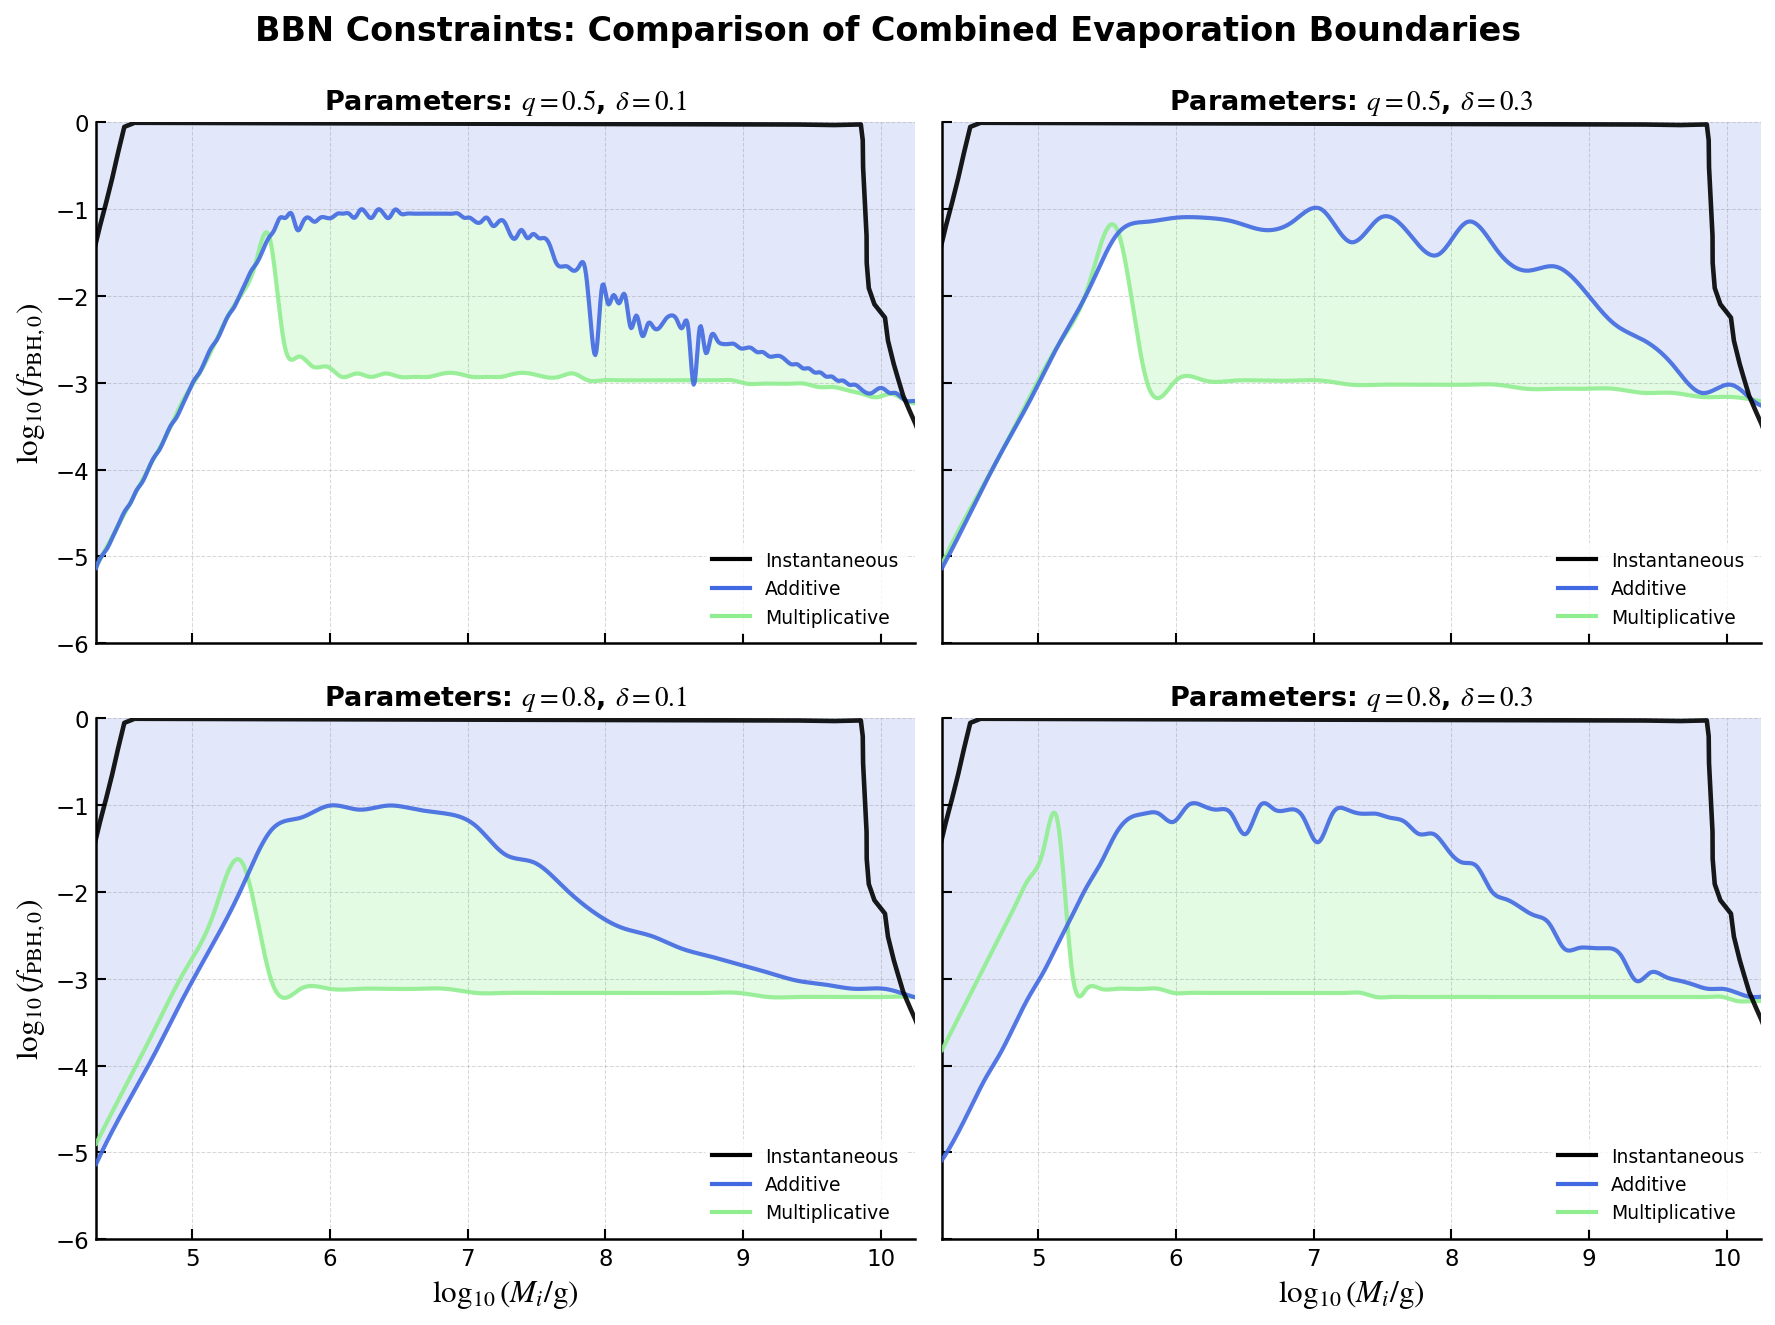

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import matplotlib as mpl
import os
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

# --- 出版级排版全局设置 ---
mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 15,
    'axes.titlesize': 13,
    'legend.fontsize': 9.0, # 适当缩小字体以适应右下角有限的空间
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'axes.linewidth': 1.2,
    'mathtext.fontset': 'stix', 
    'font.family': 'sans-serif',
})

# --- 定义 4 组参数组合 (q, delta) ---
selected_groups = [
    ("0.5", "0.1"),
    ("0.5", "0.3"),
    ("0.8", "0.1"),
    ("0.8", "0.3")
]

# 【请确认】将这里的字符串替换为你实际的 instantaneous 数据文件名
file_inst = "instantaneous.csv"

# 精确指定 X 轴的数据范围
x_start = 4.30102999566398
x_end = 10.25  # 【修改处】修改右界为 10.25
x_common = np.linspace(x_start, x_end, 800)

fig, axs = plt.subplots(2, 2, figsize=(12, 9), dpi=150, sharex=True, sharey=True)
axs_flat = axs.flatten()

# --- 核心绘图循环 ---
for idx, (q, delta) in enumerate(selected_groups):
    ax = axs_flat[idx]
    
    file_1 = f"bbn_boundary_results_{q}_{delta}_1.csv"
    file_5 = f"bbn_boundary_results_{q}_{delta}_5.csv"
    
    y_add_env = None
    y_mult_env = None
    
    # 1. 绘制 Instantaneous 极限基准线 (使用 Line 直接连接数据点)
    if os.path.exists(file_inst):
        df_inst = pd.read_csv(file_inst).sort_values(by=pd.read_csv(file_inst).columns[0])
        x_inst, y_inst = df_inst.iloc[:, 0].values, df_inst.iloc[:, 1].values
        # 不进行 Spline 平滑处理
        ax.plot(x_inst, y_inst, color='black', linestyle='-', 
                linewidth=2.2, alpha=0.9, zorder=5)
    
    # 2. 提取并绘制 Additive 曲线 (使用 Spline)
    if os.path.exists(file_1):
        df_add = pd.read_csv(file_1).sort_values(by=pd.read_csv(file_1).columns[0])
        x_add, y_add = df_add.iloc[:, 0].values, df_add.iloc[:, 1].values
        
        y_add_env = make_interp_spline(x_add, y_add, k=3)(x_common)
        ax.plot(x_common, y_add_env, color='royalblue', linestyle='-', 
                linewidth=2.0, alpha=0.9, zorder=4)
                
    # 3. 提取并绘制 Multiplicative 曲线 (使用 Spline)
    if os.path.exists(file_5):
        df_mult = pd.read_csv(file_5).sort_values(by=pd.read_csv(file_5).columns[0])
        x_mult, y_mult = df_mult.iloc[:, 0].values, df_mult.iloc[:, 1].values
        
        y_mult_env = make_interp_spline(x_mult, y_mult, k=3)(x_common)
        ax.plot(x_common, y_mult_env, color='#90ee90', linestyle='-', 
                linewidth=2.0, alpha=0.9, zorder=3)

    # 4. 执行阴影区域渲染 (带优先级判断)
    if y_add_env is not None and y_mult_env is not None:
        # 优先渲染 Additive 排除区 (淡蓝色)
        ax.fill_between(x_common, y_add_env, 0, facecolor='royalblue', alpha=0.15, zorder=1)
        # 渲染 Multiplicative 更严格的区域 (淡绿色)
        ax.fill_between(x_common, y_mult_env, y_add_env, 
                        where=(y_mult_env < y_add_env), 
                        facecolor='#90ee90', alpha=0.25, zorder=1)

    # 5. 子图细节修饰
    ax.set_title(f"Parameters: $q={q}$, $\delta={delta}$", fontweight='bold')
    ax.grid(True, which="major", linestyle="--", linewidth=0.5, color='grey', alpha=0.3)
    ax.tick_params(axis='both', which='major', length=5, width=1.0, direction='in')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 强制锁定 X 轴显示范围，切除 10.25 之外的白边
    ax.set_xlim(left=x_start, right=x_end)
    
    # 6. 构建并配置子图图例 (全部统一对齐到右下角)
    legend_elements = []
    if os.path.exists(file_inst):
        legend_elements.append(mlines.Line2D([0], [0], color='black', lw=2.0, label='Instantaneous'))
    if y_add_env is not None:
        legend_elements.append(mlines.Line2D([0], [0], color='royalblue', lw=2.0, label='Additive'))
    if y_mult_env is not None:
        legend_elements.append(mlines.Line2D([0], [0], color='#90ee90', lw=2.0, label='Multiplicative'))
        
    if legend_elements:
        ax.legend(handles=legend_elements, loc='lower right', framealpha=0.8, edgecolor='none')

# --- 全局轴标签与范围锁死 ---
axs[0, 0].set_ylim(-6, 0)
for ax in axs[1, :]: ax.set_xlabel(r"$\log_{10}(M_i/\mathrm{g})$")
for ax in axs[:, 0]: ax.set_ylabel(r"$\log_{10}(f_{\mathrm{PBH},0})$")

fig.suptitle("BBN Constraints: Comparison of Combined Evaporation Boundaries", 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
fig.subplots_adjust(top=0.9) 
plt.show()

<>:88: SyntaxWarning: invalid escape sequence '\d'
<>:88: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_5283/2529845151.py:88: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title(f"Parameters: $q={q}$, $\delta={delta}$", fontweight='bold')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


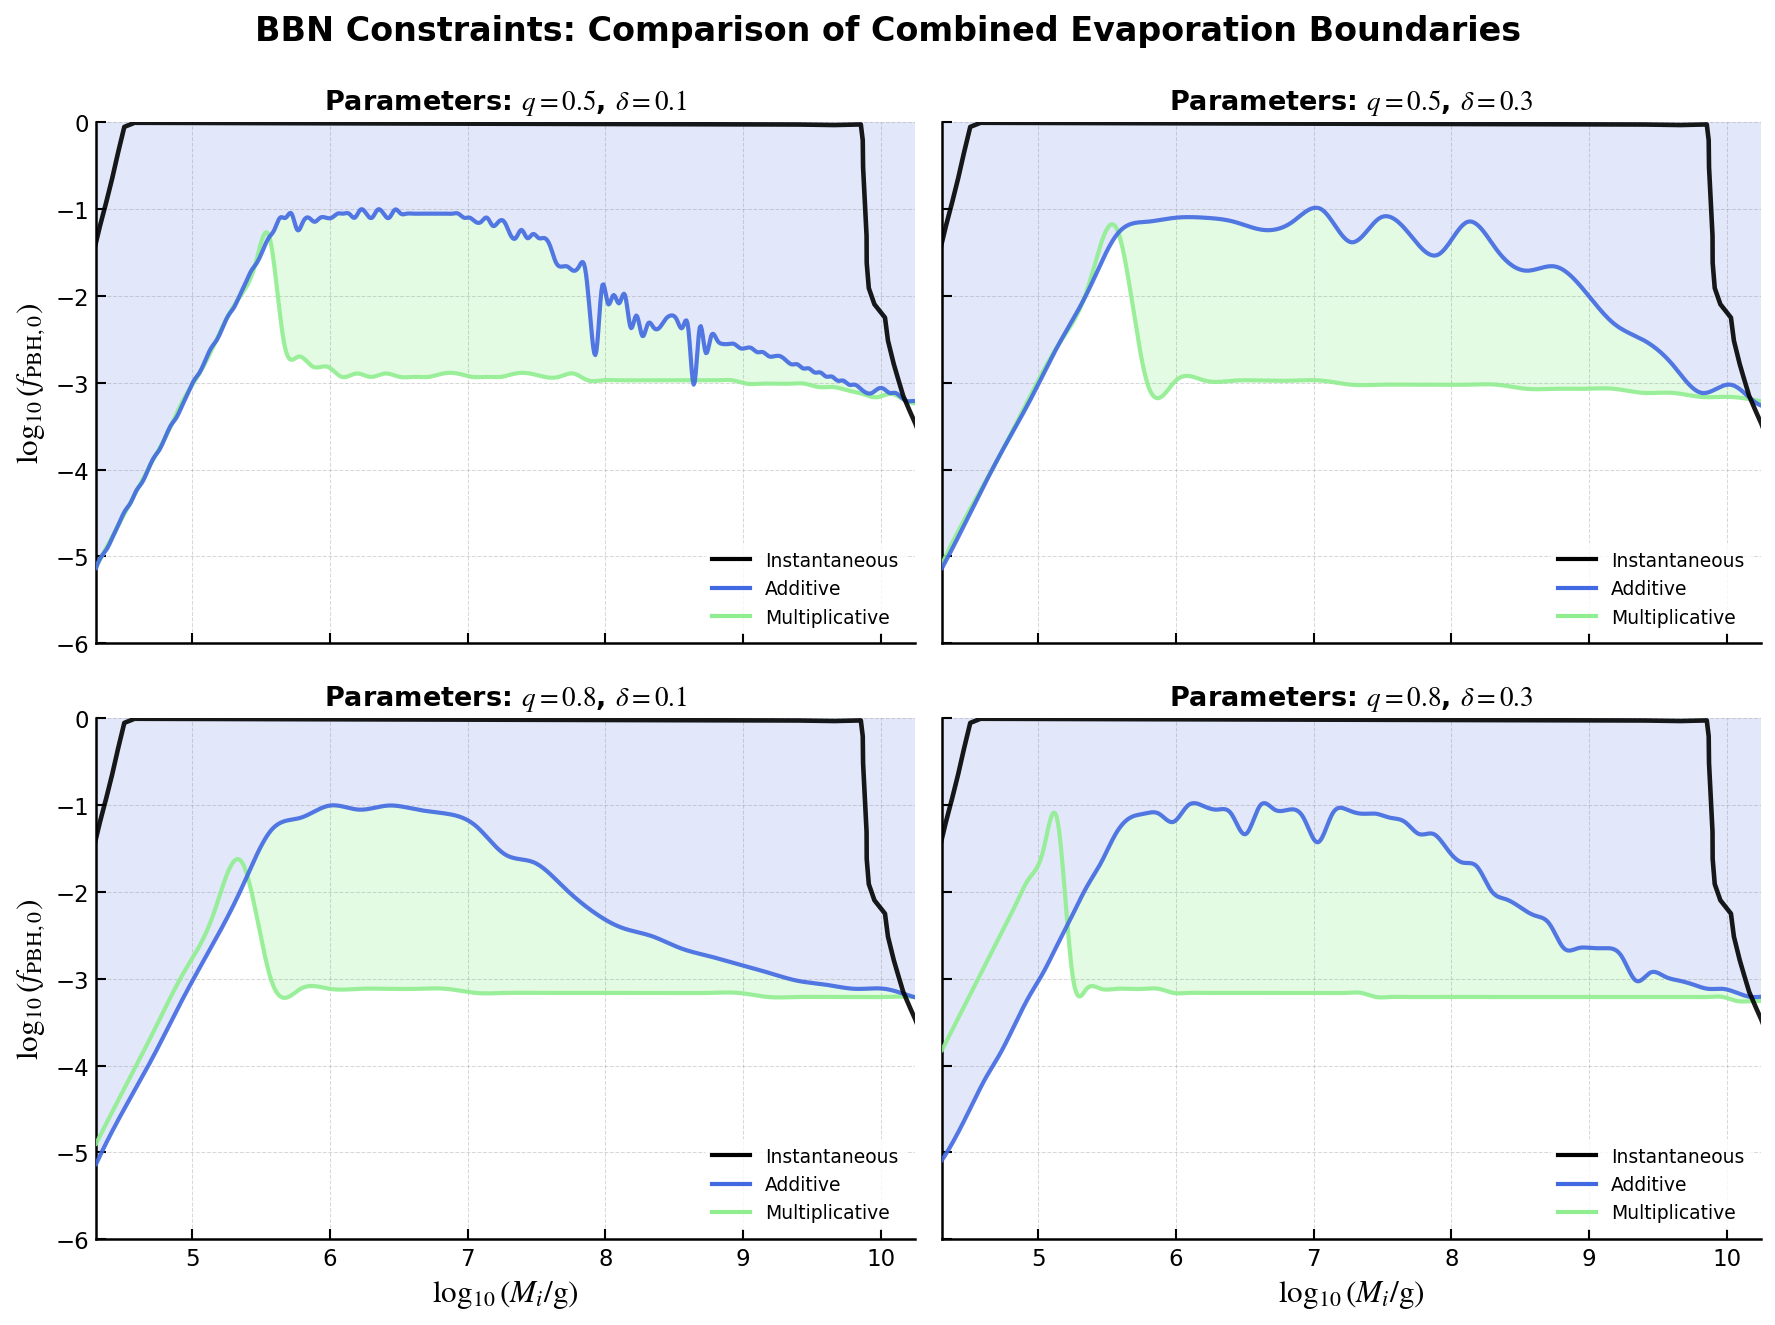

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import matplotlib as mpl
import os
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

# --- 出版级排版全局设置 ---
mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 15,
    'axes.titlesize': 13,
    'legend.fontsize': 9.0, 
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'axes.linewidth': 1.2,
    'mathtext.fontset': 'stix', 
    'font.family': 'sans-serif',
    # 【修改处 1：强制嵌入真实字体，确保机器可读，防止被转为不可读的线条】
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# --- 定义 4 组参数组合 (q, delta) ---
selected_groups = [
    ("0.5", "0.1"),
    ("0.5", "0.3"),
    ("0.8", "0.1"),
    ("0.8", "0.3")
]

# 【请确认】将这里的字符串替换为你实际的 instantaneous 数据文件名
file_inst = "instantaneous.csv"

# 精确指定 X 轴的数据范围
x_start = 4.30102999566398
x_end = 10.25  
x_common = np.linspace(x_start, x_end, 800)

fig, axs = plt.subplots(2, 2, figsize=(12, 9), dpi=150, sharex=True, sharey=True)
axs_flat = axs.flatten()

# --- 核心绘图循环 ---
for idx, (q, delta) in enumerate(selected_groups):
    ax = axs_flat[idx]
    
    file_1 = f"bbn_boundary_results_{q}_{delta}_1.csv"
    file_5 = f"bbn_boundary_results_{q}_{delta}_5.csv"
    
    y_add_env = None
    y_mult_env = None
    
    # 1. 绘制 Instantaneous 极限基准线
    if os.path.exists(file_inst):
        df_inst = pd.read_csv(file_inst).sort_values(by=pd.read_csv(file_inst).columns[0])
        x_inst, y_inst = df_inst.iloc[:, 0].values, df_inst.iloc[:, 1].values
        ax.plot(x_inst, y_inst, color='black', linestyle='-', 
                linewidth=2.2, alpha=0.9, zorder=5)
    
    # 2. 提取并绘制 Additive 曲线
    if os.path.exists(file_1):
        df_add = pd.read_csv(file_1).sort_values(by=pd.read_csv(file_1).columns[0])
        x_add, y_add = df_add.iloc[:, 0].values, df_add.iloc[:, 1].values
        
        y_add_env = make_interp_spline(x_add, y_add, k=3)(x_common)
        ax.plot(x_common, y_add_env, color='royalblue', linestyle='-', 
                linewidth=2.0, alpha=0.9, zorder=4)
                
    # 3. 提取并绘制 Multiplicative 曲线
    if os.path.exists(file_5):
        df_mult = pd.read_csv(file_5).sort_values(by=pd.read_csv(file_5).columns[0])
        x_mult, y_mult = df_mult.iloc[:, 0].values, df_mult.iloc[:, 1].values
        
        y_mult_env = make_interp_spline(x_mult, y_mult, k=3)(x_common)
        ax.plot(x_common, y_mult_env, color='#90ee90', linestyle='-', 
                linewidth=2.0, alpha=0.9, zorder=3)

    # 4. 执行阴影区域渲染 (注意：这里的 alpha 参数在 EPS 中可能会失效或变黑)
    if y_add_env is not None and y_mult_env is not None:
        ax.fill_between(x_common, y_add_env, 0, facecolor='royalblue', alpha=0.15, zorder=1)
        ax.fill_between(x_common, y_mult_env, y_add_env, 
                        where=(y_mult_env < y_add_env), 
                        facecolor='#90ee90', alpha=0.25, zorder=1)

    # 5. 子图细节修饰
    ax.set_title(f"Parameters: $q={q}$, $\delta={delta}$", fontweight='bold')
    ax.grid(True, which="major", linestyle="--", linewidth=0.5, color='grey', alpha=0.3)
    ax.tick_params(axis='both', which='major', length=5, width=1.0, direction='in')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.set_xlim(left=x_start, right=x_end)
    
    # 6. 构建并配置子图图例
    legend_elements = []
    if os.path.exists(file_inst):
        legend_elements.append(mlines.Line2D([0], [0], color='black', lw=2.0, label='Instantaneous'))
    if y_add_env is not None:
        legend_elements.append(mlines.Line2D([0], [0], color='royalblue', lw=2.0, label='Additive'))
    if y_mult_env is not None:
        legend_elements.append(mlines.Line2D([0], [0], color='#90ee90', lw=2.0, label='Multiplicative'))
        
    if legend_elements:
        ax.legend(handles=legend_elements, loc='lower right', framealpha=0.8, edgecolor='none')

# --- 全局轴标签与范围锁死 ---
axs[0, 0].set_ylim(-6, 0)
for ax in axs[1, :]: ax.set_xlabel(r"$\log_{10}(M_i/\mathrm{g})$")
for ax in axs[:, 0]: ax.set_ylabel(r"$\log_{10}(f_{\mathrm{PBH},0})$")

fig.suptitle("BBN Constraints: Comparison of Combined Evaporation Boundaries", 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
fig.subplots_adjust(top=0.9) 

# 【修改处 2：在此处添加保存文件的代码，必须放在 plt.show() 之前】
# 导出 EPS 格式
plt.savefig("bbn_constraints_plot.eps", format='eps', bbox_inches='tight')

# 极力推荐的替代方案：导出为 PDF，解决 alpha 透明度在 EPS 中的兼容问题
plt.savefig("bbn_constraints_plot.pdf", format='pdf', bbox_inches='tight')

# 网页端显示
plt.show()

<>:91: SyntaxWarning: invalid escape sequence '\d'
<>:91: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_5283/3480916240.py:91: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title(f"Parameters: $q={q}$, $\delta={delta}$", fontweight='bold')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


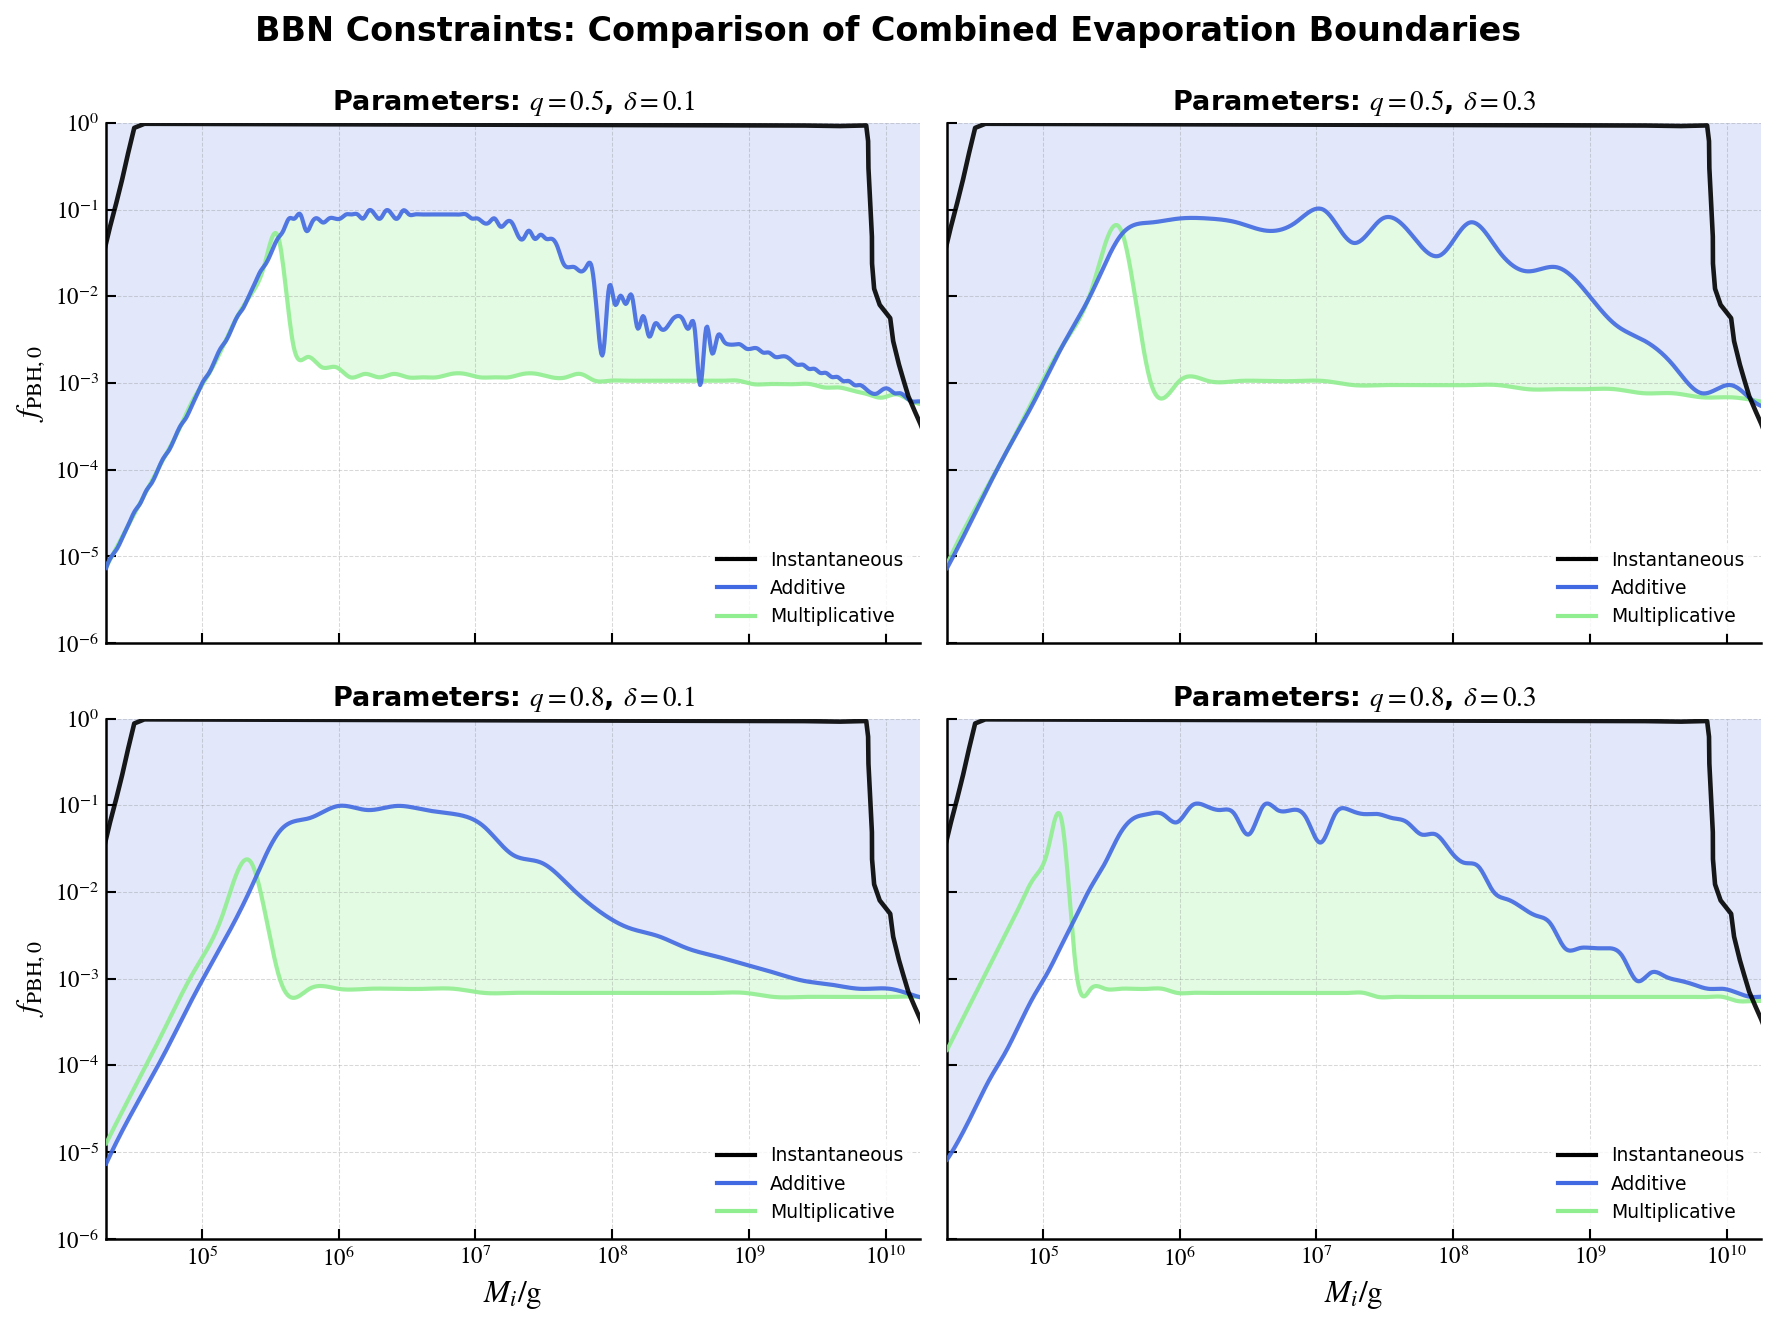

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import matplotlib as mpl
import os
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker  # 【新增】导入刻度格式化工具

# --- 出版级排版全局设置 ---
mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 15,
    'axes.titlesize': 13,
    'legend.fontsize': 9.0, 
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'axes.linewidth': 1.2,
    'mathtext.fontset': 'stix', 
    'font.family': 'sans-serif',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# --- 定义 4 组参数组合 (q, delta) ---
selected_groups = [
    ("0.5", "0.1"),
    ("0.5", "0.3"),
    ("0.8", "0.1"),
    ("0.8", "0.3")
]

file_inst = "instantaneous.csv"

# 精确指定 X 轴的数据范围
x_start = 4.30102999566398
x_end = 10.25  
x_common = np.linspace(x_start, x_end, 800)

fig, axs = plt.subplots(2, 2, figsize=(12, 9), dpi=150, sharex=True, sharey=True)
axs_flat = axs.flatten()

# 【新增】定义一个格式化函数，将线性数值 x 转化为 10^x 格式的字符串
def log_formatter(x, pos):
    # {x:g} 可以自动去掉整数后多余的 .0，例如 5.0 会显示为 5，5.5 保持 5.5
    return rf"$10^{{{x:g}}}$"

# --- 核心绘图循环 ---
for idx, (q, delta) in enumerate(selected_groups):
    ax = axs_flat[idx]
    
    file_1 = f"bbn_boundary_results_{q}_{delta}_1.csv"
    file_5 = f"bbn_boundary_results_{q}_{delta}_5.csv"
    
    y_add_env = None
    y_mult_env = None
    
    # 1. 绘制 Instantaneous 极限基准线
    if os.path.exists(file_inst):
        df_inst = pd.read_csv(file_inst).sort_values(by=pd.read_csv(file_inst).columns[0])
        x_inst, y_inst = df_inst.iloc[:, 0].values, df_inst.iloc[:, 1].values
        ax.plot(x_inst, y_inst, color='black', linestyle='-', 
                linewidth=2.2, alpha=0.9, zorder=5)
    
    # 2. 提取并绘制 Additive 曲线
    if os.path.exists(file_1):
        df_add = pd.read_csv(file_1).sort_values(by=pd.read_csv(file_1).columns[0])
        x_add, y_add = df_add.iloc[:, 0].values, df_add.iloc[:, 1].values
        
        y_add_env = make_interp_spline(x_add, y_add, k=3)(x_common)
        ax.plot(x_common, y_add_env, color='royalblue', linestyle='-', 
                linewidth=2.0, alpha=0.9, zorder=4)
                
    # 3. 提取并绘制 Multiplicative 曲线
    if os.path.exists(file_5):
        df_mult = pd.read_csv(file_5).sort_values(by=pd.read_csv(file_5).columns[0])
        x_mult, y_mult = df_mult.iloc[:, 0].values, df_mult.iloc[:, 1].values
        
        y_mult_env = make_interp_spline(x_mult, y_mult, k=3)(x_common)
        ax.plot(x_common, y_mult_env, color='#90ee90', linestyle='-', 
                linewidth=2.0, alpha=0.9, zorder=3)

    if y_add_env is not None and y_mult_env is not None:
        ax.fill_between(x_common, y_add_env, 0, facecolor='royalblue', alpha=0.15, zorder=1)
        ax.fill_between(x_common, y_mult_env, y_add_env, 
                        where=(y_mult_env < y_add_env), 
                        facecolor='#90ee90', alpha=0.25, zorder=1)

    # 5. 子图细节修饰
    ax.set_title(f"Parameters: $q={q}$, $\delta={delta}$", fontweight='bold')
    ax.grid(True, which="major", linestyle="--", linewidth=0.5, color='grey', alpha=0.3)
    ax.tick_params(axis='both', which='major', length=5, width=1.0, direction='in')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.set_xlim(left=x_start, right=x_end)
    
    # 【新增】将刚才写好的格式化函数应用到 X 轴和 Y 轴上
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(log_formatter))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(log_formatter))
    
    # 6. 构建并配置子图图例
    legend_elements = []
    if os.path.exists(file_inst):
        legend_elements.append(mlines.Line2D([0], [0], color='black', lw=2.0, label='Instantaneous'))
    if y_add_env is not None:
        legend_elements.append(mlines.Line2D([0], [0], color='royalblue', lw=2.0, label='Additive'))
    if y_mult_env is not None:
        legend_elements.append(mlines.Line2D([0], [0], color='#90ee90', lw=2.0, label='Multiplicative'))
        
    if legend_elements:
        ax.legend(handles=legend_elements, loc='lower right', framealpha=0.8, edgecolor='none')

# --- 全局轴标签与范围锁死 ---
axs[0, 0].set_ylim(-6, 0)

# 【修改】刻度已经显示为指数了，坐标轴标签就不用写 log_10 了，恢复真实的物理量表示
for ax in axs[1, :]: ax.set_xlabel(r"$M_i/\mathrm{g}$")
for ax in axs[:, 0]: ax.set_ylabel(r"$f_{\mathrm{PBH},0}$")

fig.suptitle("BBN Constraints: Comparison of Combined Evaporation Boundaries", 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
fig.subplots_adjust(top=0.9) 

plt.savefig("bbn_constraints_plot.eps", format='eps', bbox_inches='tight')
plt.savefig("bbn_constraints_plot.pdf", format='pdf', bbox_inches='tight')
plt.show()

<>:89: SyntaxWarning: invalid escape sequence '\d'
<>:89: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1428/3348459848.py:89: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title(f"Parameters: $q={q}$, $\delta={delta}$", fontweight='bold')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


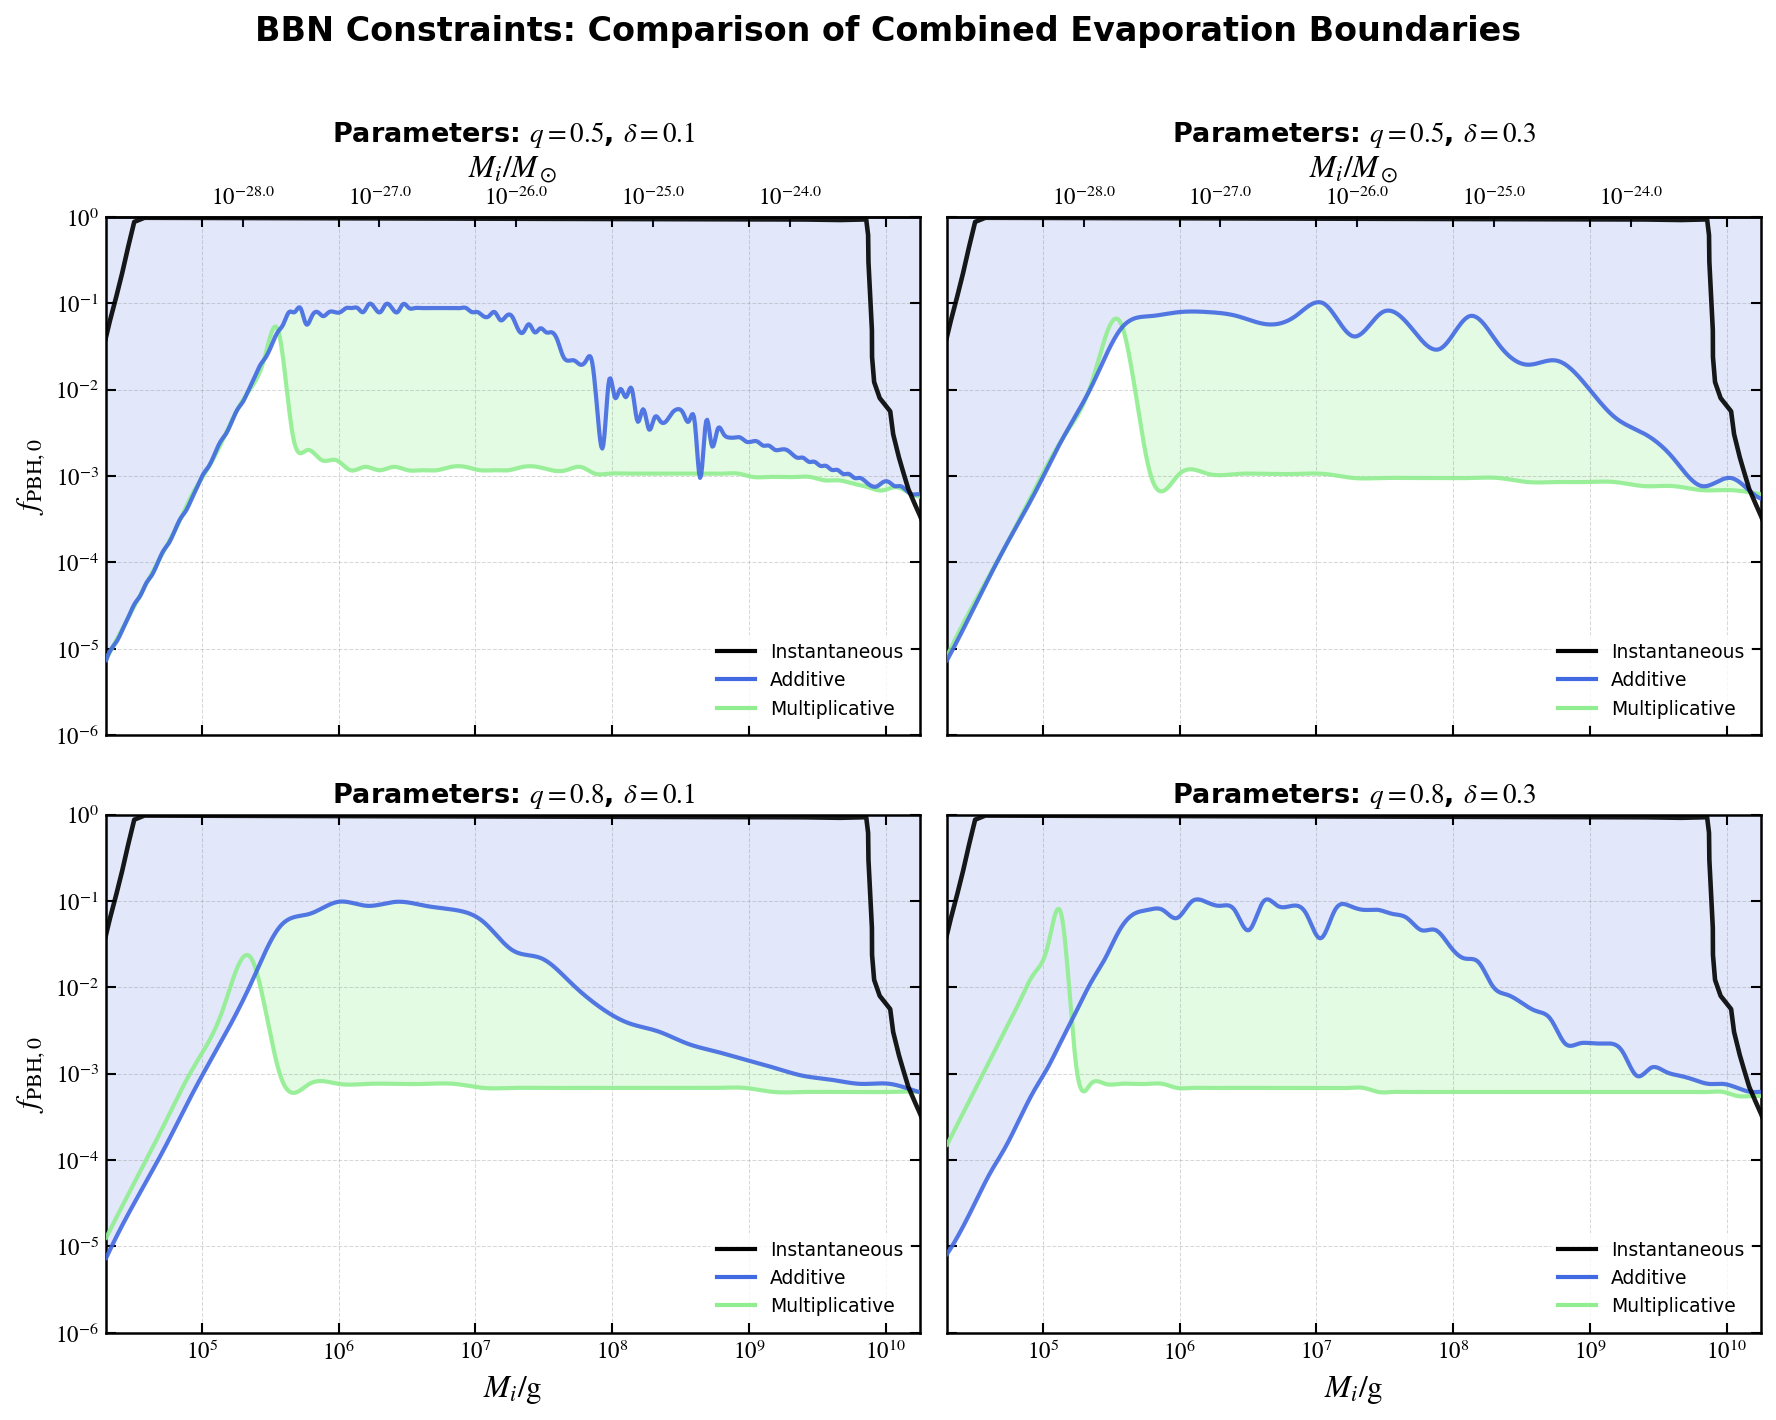

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import matplotlib as mpl
import os
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker  

# --- 出版级排版全局设置 ---
mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 15,
    'axes.titlesize': 13,
    'legend.fontsize': 9.0, 
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'axes.linewidth': 1.2,
    'mathtext.fontset': 'stix', 
    'font.family': 'sans-serif',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

selected_groups = [
    ("0.5", "0.1"),
    ("0.5", "0.3"),
    ("0.8", "0.1"),
    ("0.8", "0.3")
]

file_inst = "instantaneous.csv"

x_start = 4.30102999566398
x_end = 10.25  
x_common = np.linspace(x_start, x_end, 800)

fig, axs = plt.subplots(2, 2, figsize=(12, 9), dpi=150, sharex=True, sharey=True)
axs_flat = axs.flatten()

# --- 刻度格式化函数 ---
def log_formatter(x, pos):
    return rf"$10^{{{x:g}}}$"

# 【新增】针对顶部太阳质量坐标轴的格式化函数（保留一位小数，显得更整洁）
def solar_log_formatter(x, pos):
    return rf"$10^{{{x:.1f}}}$"

# --- 核心绘图循环 ---
for idx, (q, delta) in enumerate(selected_groups):
    ax = axs_flat[idx]
    
    file_1 = f"bbn_boundary_results_{q}_{delta}_1.csv"
    file_5 = f"bbn_boundary_results_{q}_{delta}_5.csv"
    
    y_add_env = None
    y_mult_env = None
    
    if os.path.exists(file_inst):
        df_inst = pd.read_csv(file_inst).sort_values(by=pd.read_csv(file_inst).columns[0])
        x_inst, y_inst = df_inst.iloc[:, 0].values, df_inst.iloc[:, 1].values
        ax.plot(x_inst, y_inst, color='black', linestyle='-', 
                linewidth=2.2, alpha=0.9, zorder=5)
    
    if os.path.exists(file_1):
        df_add = pd.read_csv(file_1).sort_values(by=pd.read_csv(file_1).columns[0])
        x_add, y_add = df_add.iloc[:, 0].values, df_add.iloc[:, 1].values
        
        y_add_env = make_interp_spline(x_add, y_add, k=3)(x_common)
        ax.plot(x_common, y_add_env, color='royalblue', linestyle='-', 
                linewidth=2.0, alpha=0.9, zorder=4)
                
    if os.path.exists(file_5):
        df_mult = pd.read_csv(file_5).sort_values(by=pd.read_csv(file_5).columns[0])
        x_mult, y_mult = df_mult.iloc[:, 0].values, df_mult.iloc[:, 1].values
        
        y_mult_env = make_interp_spline(x_mult, y_mult, k=3)(x_common)
        ax.plot(x_common, y_mult_env, color='#90ee90', linestyle='-', 
                linewidth=2.0, alpha=0.9, zorder=3)

    if y_add_env is not None and y_mult_env is not None:
        ax.fill_between(x_common, y_add_env, 0, facecolor='royalblue', alpha=0.15, zorder=1)
        ax.fill_between(x_common, y_mult_env, y_add_env, 
                        where=(y_mult_env < y_add_env), 
                        facecolor='#90ee90', alpha=0.25, zorder=1)

    # 5. 子图细节修饰
    ax.set_title(f"Parameters: $q={q}$, $\delta={delta}$", fontweight='bold')
    ax.grid(True, which="major", linestyle="--", linewidth=0.5, color='grey', alpha=0.3)
    
    # 【修改 1】开启 top 和 right 的刻度线，并设置向内 (in)，形成完整的边框感
    ax.tick_params(axis='both', which='major', length=5, width=1.0, 
                   direction='in', top=True, right=True)
                   
    # 【修改 2】删除隐藏 top 和 right 边框的代码，让它们保持显示 (封闭起来)
    # ax.spines['top'].set_visible(False)   <-- 已删除
    # ax.spines['right'].set_visible(False) <-- 已删除
    
    ax.set_xlim(left=x_start, right=x_end)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(log_formatter))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(log_formatter))
    
    legend_elements = []
    if os.path.exists(file_inst):
        legend_elements.append(mlines.Line2D([0], [0], color='black', lw=2.0, label='Instantaneous'))
    if y_add_env is not None:
        legend_elements.append(mlines.Line2D([0], [0], color='royalblue', lw=2.0, label='Additive'))
    if y_mult_env is not None:
        legend_elements.append(mlines.Line2D([0], [0], color='#90ee90', lw=2.0, label='Multiplicative'))
        
    if legend_elements:
        ax.legend(handles=legend_elements, loc='lower right', framealpha=0.8, edgecolor='none')

# --- 全局轴标签与范围锁死 ---
axs[0, 0].set_ylim(-6, 0)
for ax in axs[1, :]: ax.set_xlabel(r"$M_i/\mathrm{g}$")
for ax in axs[:, 0]: ax.set_ylabel(r"$f_{\mathrm{PBH},0}$")

# 【新增】为第一行的子图（第一、二象限）添加顶部的太阳质量坐标轴
M_sun_g = 1.98847e33
log_M_sun = np.log10(M_sun_g) # 大约是 33.2985

# 定义正向和逆向的坐标映射函数
def g_to_solar(x):
    return x - log_M_sun

def solar_to_g(x):
    return x + log_M_sun

for ax in axs[0, :]:
    # 创建副坐标轴
    secax = ax.secondary_xaxis('top', functions=(g_to_solar, solar_to_g))
    secax.set_xlabel(r"$M_i/M_\odot$")
    secax.xaxis.set_major_formatter(ticker.FuncFormatter(solar_log_formatter))
    secax.tick_params(axis='x', which='major', length=5, width=1.0, direction='in')

fig.suptitle("BBN Constraints: Comparison of Combined Evaporation Boundaries", 
             fontsize=16, fontweight='bold', y=1.05) # 稍微抬高主标题，给顶部坐标轴留出空间

plt.tight_layout()
fig.subplots_adjust(top=0.9) 

plt.savefig("bbn_constraints_plot.eps", format='eps', bbox_inches='tight')
plt.savefig("bbn_constraints_plot.pdf", format='pdf', bbox_inches='tight')
plt.show()

<>:85: SyntaxWarning: invalid escape sequence '\d'
<>:85: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1428/2474103659.py:85: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title(f"Parameters: $q={q}$, $\delta={delta}$", fontweight='bold')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


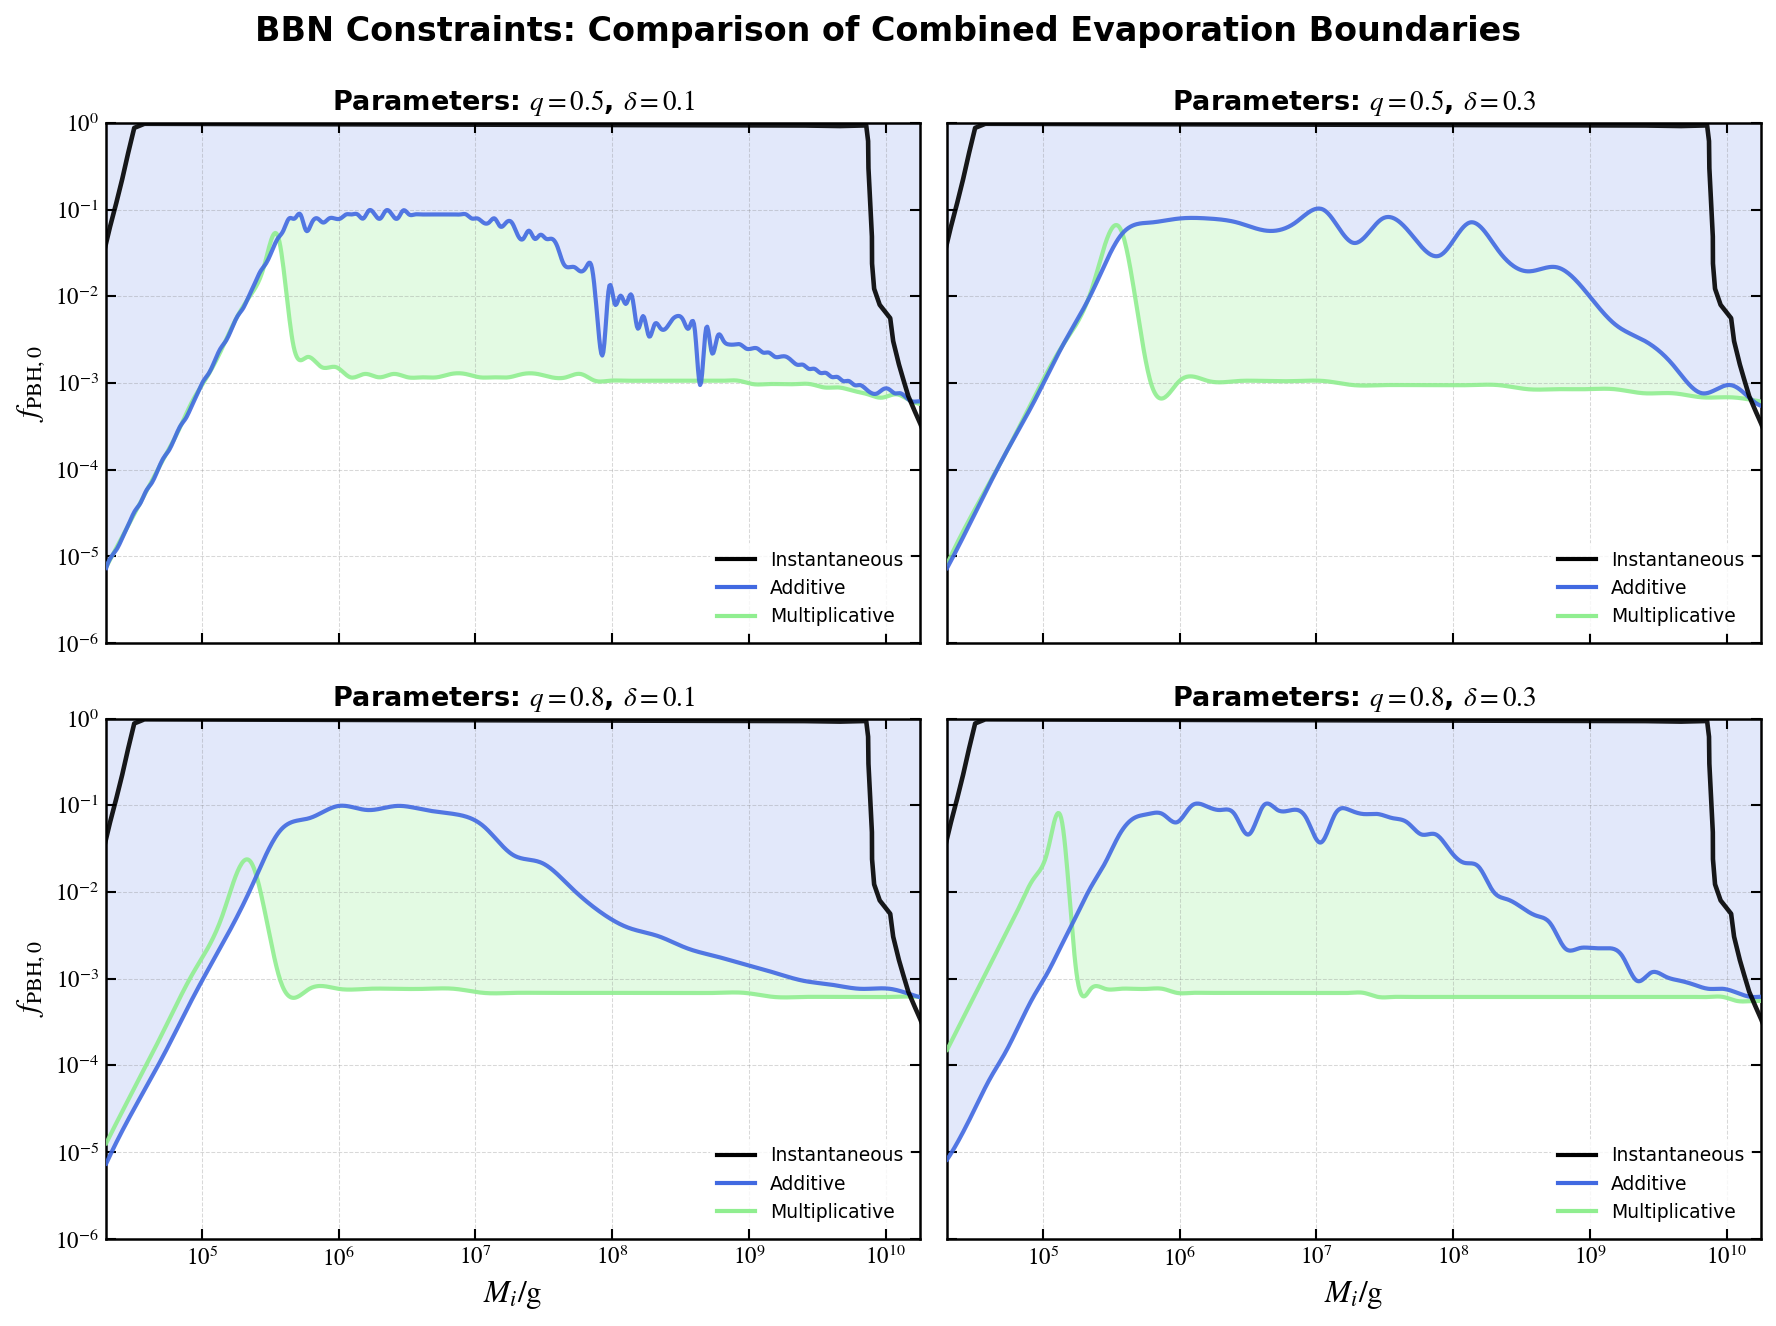

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import matplotlib as mpl
import os
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker  

# --- 出版级排版全局设置 ---
mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 15,
    'axes.titlesize': 13,
    'legend.fontsize': 9.0, 
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'axes.linewidth': 1.2,
    'mathtext.fontset': 'stix', 
    'font.family': 'sans-serif',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

selected_groups = [
    ("0.5", "0.1"),
    ("0.5", "0.3"),
    ("0.8", "0.1"),
    ("0.8", "0.3")
]

file_inst = "instantaneous.csv"

x_start = 4.30102999566398
x_end = 10.25  
x_common = np.linspace(x_start, x_end, 800)

fig, axs = plt.subplots(2, 2, figsize=(12, 9), dpi=150, sharex=True, sharey=True)
axs_flat = axs.flatten()

# --- 刻度格式化函数 ---
def log_formatter(x, pos):
    return rf"$10^{{{x:g}}}$"

# --- 核心绘图循环 ---
for idx, (q, delta) in enumerate(selected_groups):
    ax = axs_flat[idx]
    
    file_1 = f"bbn_boundary_results_{q}_{delta}_1.csv"
    file_5 = f"bbn_boundary_results_{q}_{delta}_5.csv"
    
    y_add_env = None
    y_mult_env = None
    
    if os.path.exists(file_inst):
        df_inst = pd.read_csv(file_inst).sort_values(by=pd.read_csv(file_inst).columns[0])
        x_inst, y_inst = df_inst.iloc[:, 0].values, df_inst.iloc[:, 1].values
        ax.plot(x_inst, y_inst, color='black', linestyle='-', 
                linewidth=2.2, alpha=0.9, zorder=5)
    
    if os.path.exists(file_1):
        df_add = pd.read_csv(file_1).sort_values(by=pd.read_csv(file_1).columns[0])
        x_add, y_add = df_add.iloc[:, 0].values, df_add.iloc[:, 1].values
        
        y_add_env = make_interp_spline(x_add, y_add, k=3)(x_common)
        ax.plot(x_common, y_add_env, color='royalblue', linestyle='-', 
                linewidth=2.0, alpha=0.9, zorder=4)
                
    if os.path.exists(file_5):
        df_mult = pd.read_csv(file_5).sort_values(by=pd.read_csv(file_5).columns[0])
        x_mult, y_mult = df_mult.iloc[:, 0].values, df_mult.iloc[:, 1].values
        
        y_mult_env = make_interp_spline(x_mult, y_mult, k=3)(x_common)
        ax.plot(x_common, y_mult_env, color='#90ee90', linestyle='-', 
                linewidth=2.0, alpha=0.9, zorder=3)

    if y_add_env is not None and y_mult_env is not None:
        ax.fill_between(x_common, y_add_env, 0, facecolor='royalblue', alpha=0.15, zorder=1)
        ax.fill_between(x_common, y_mult_env, y_add_env, 
                        where=(y_mult_env < y_add_env), 
                        facecolor='#90ee90', alpha=0.25, zorder=1)

    # 5. 子图细节修饰
    ax.set_title(f"Parameters: $q={q}$, $\delta={delta}$", fontweight='bold')
    ax.grid(True, which="major", linestyle="--", linewidth=0.5, color='grey', alpha=0.3)
    
    # 【保留】开启 top 和 right 的刻度线，并设置向内 (in)，形成完整的边框感
    ax.tick_params(axis='both', which='major', length=5, width=1.0, 
                   direction='in', top=True, right=True)
                   
    ax.set_xlim(left=x_start, right=x_end)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(log_formatter))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(log_formatter))
    
    legend_elements = []
    if os.path.exists(file_inst):
        legend_elements.append(mlines.Line2D([0], [0], color='black', lw=2.0, label='Instantaneous'))
    if y_add_env is not None:
        legend_elements.append(mlines.Line2D([0], [0], color='royalblue', lw=2.0, label='Additive'))
    if y_mult_env is not None:
        legend_elements.append(mlines.Line2D([0], [0], color='#90ee90', lw=2.0, label='Multiplicative'))
        
    if legend_elements:
        ax.legend(handles=legend_elements, loc='lower right', framealpha=0.8, edgecolor='none')

# --- 全局轴标签与范围锁死 ---
axs[0, 0].set_ylim(-6, 0)
for ax in axs[1, :]: ax.set_xlabel(r"$M_i/\mathrm{g}$")
for ax in axs[:, 0]: ax.set_ylabel(r"$f_{\mathrm{PBH},0}$")

# 【恢复】将大标题的 y 值调回 0.98，让整体布局更紧凑
fig.suptitle("BBN Constraints: Comparison of Combined Evaporation Boundaries", 
             fontsize=16, fontweight='bold', y=0.98) 

plt.tight_layout()
fig.subplots_adjust(top=0.9) 

plt.savefig("bbn_constraints_plot.eps", format='eps', bbox_inches='tight')
plt.savefig("bbn_constraints_plot.pdf", format='pdf', bbox_inches='tight')
plt.show()